# SDLC Automate App

Enhancing the Software Development Life Cycle through the Integration of Generative Artificial Intelligence

## 1. Installation and Setup

First, let's install all required packages:

In [ ]:
# Install required packages
!pip install streamlit==1.38.0
!pip install PyPDF2==3.0.1
!pip install python-docx==0.8.11
!pip install python-pptx==0.6.21
!pip install pandas==2.1.1
!pip install openai==1.71.0
!pip install langchain==0.3.0
!pip install langchain-openai==0.3.12
!pip install faiss-cpu==1.8.0
!pip install langchain-community==0.3.0
!pip install langchain-core==0.3.50
!pip install scikit-learn==1.6.1
!pip install openpyxl==3.1.5
!pip install langchain-google-genai==2.1.2
!pip install numpy==1.26.4

INFO: pip is looking at multiple versions of langchain-core to determine which version is compatible with other requirements. This could take a while.
  Using cached langchain_core-0.3.75-py3-none-any.whl.metadata (5.7 kB)
  Using cached langchain_core-0.3.74-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_core-0.3.73-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_core-0.3.72-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_core-0.3.71-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_core-0.3.70-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_core-0.3.69-py3-none-any.whl.metadata (5.8 kB)
INFO: pip is still looking at multiple versions of langchain-core to determine which version is compatible with other requirements. This could take a while.
  Using cached langchain_core-0.3.68-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_core-0.3.67-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_core-0.3.66-py3-non

## 2. Import Required Libraries

In [ ]:
# Import all required libraries
from PyPDF2 import PdfReader
from docx import Document
import pptx
import pandas as pd
import os
from google.colab import userdata
import time
from langchain.chains.retrieval_qa.base import RetrievalQA
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

## 3. API Key Configuration

Set up your API keys for OpenAI and Google AI:

In [ ]:
# Set up API keys - Replace with your actual API keys
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

# Verify API keys are set
print("OpenAI API Key set:", "OPENAI_API_KEY" in os.environ and bool(os.environ["OPENAI_API_KEY"]))
print("Google API Key set:", "GOOGLE_API_KEY" in os.environ and bool(os.environ["GOOGLE_API_KEY"]))

OpenAI API Key set: True
Google API Key set: True


## 4. Confidence and Quality Assessment Functions

In [ ]:
def calculate_confidence_level(prompt, answer):
    """Calculate confidence level based on how well the answer addresses the prompt."""
    try:
        # Preprocess texts
        prompt_clean = re.sub(r'[^\w\s]', '', prompt.lower())
        answer_clean = re.sub(r'[^\w\s]', '', answer.lower())

        # Extract key terms from prompt
        prompt_keywords = set(prompt_clean.split())
        answer_words = set(answer_clean.split())

        # Calculate keyword overlap
        common_keywords = prompt_keywords.intersection(answer_words)
        keyword_overlap = len(common_keywords) / len(prompt_keywords) if prompt_keywords else 0

        # Use TF-IDF for semantic similarity
        vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
        tfidf_matrix = vectorizer.fit_transform([prompt_clean, answer_clean])
        similarity_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

        # Combined confidence score (weighted average)
        confidence_score = (keyword_overlap * 0.3 + similarity_score * 0.7) * 100

        return min(confidence_score, 100)  # Cap at 100%
    except Exception as e:
        print(f"Error calculating confidence: {str(e)}")
        return 0

def calculate_match_percentage(answer, source_text):
    """Calculate how well the answer matches the source document content."""
    try:
        # Preprocess texts
        answer_clean = re.sub(r'[^\w\s]', '', answer.lower())
        source_clean = re.sub(r'[^\w\s]', '', source_text.lower())

        # Use TF-IDF for document similarity
        vectorizer = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1, 2))
        tfidf_matrix = vectorizer.fit_transform([source_clean, answer_clean])
        match_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

        # Convert to percentage
        match_percentage = match_score * 100

        return min(match_percentage, 100)  # Cap at 100%
    except Exception as e:
        print(f"Error calculating match percentage: {str(e)}")
        return 0

def get_confidence_category(percentage):
    """Convert percentage to confidence level category."""
    if percentage >= 70:
        return "High", "🟢"
    elif percentage >= 30:
        return "Medium", "🟡"
    else:
        return "Low", "🔴"

def display_confidence_metrics(confidence_score, match_score):
    """Display confidence and match metrics in a formatted way."""
    conf_level, conf_icon = get_confidence_category(confidence_score)
    match_level, match_icon = get_confidence_category(match_score)

    print(f"\n📊 Quality Assessment:")
    print(f"{conf_icon} Confidence Level: {conf_level} ({confidence_score:.1f}%)")
    print(f"{match_icon} Match Percentage: {match_level} ({match_score:.1f}%)")

    # Overall assessment
    overall_score = (confidence_score + match_score) / 2
    overall_level, overall_icon = get_confidence_category(overall_score)

    print(f"{overall_icon} Overall Assessment: {overall_level} ({overall_score:.1f}%)")
    print("-" * 50)

## 5. File Processing Functions

In [ ]:
def extract_text_from_file(file_path):
    """Extracts text based on file type."""
    text = ""
    file_ext = os.path.splitext(file_path)[1].lower()

    try:
        # Handle PDF files
        if file_ext == ".pdf":
            with open(file_path, 'rb') as file:
                pdf_reader = PdfReader(file)
                for page in pdf_reader.pages:
                    text += page.extract_text()

        # Handle Word (.docx) files
        elif file_ext == ".docx":
            doc = Document(file_path)
            for para in doc.paragraphs:
                text += para.text + "\n"

        # Handle text (.txt) files
        elif file_ext == ".txt":
            with open(file_path, 'r', encoding='utf-8') as file:
                text = file.read()

        # Handle Excel files (.xlsx, .xls)
        elif file_ext in [".xlsx", ".xls"]:
            df = pd.read_excel(file_path)
            text = df.to_string()

        # Handle PowerPoint files (.pptx, .ppt)
        elif file_ext in [".pptx", ".ppt"]:
            ppt = pptx.Presentation(file_path)
            for slide in ppt.slides:
                for shape in slide.shapes:
                    if hasattr(shape, "text"):
                        text += shape.text + "\n"

        print(f"✅ Successfully extracted {len(text)} characters from {file_path}")
        return text

    except Exception as e:
        print(f"❌ Error extracting text from {file_path}: {str(e)}")
        return ""

def create_vector_store(text):
    """Create vector store from extracted text."""
    try:
        text_splitter = RecursiveCharacterTextSplitter(
            separators="\n",
            chunk_size=2000,
            chunk_overlap=100,
            length_function=len
        )
        chunks = text_splitter.split_text(text)
        embeddings = OpenAIEmbeddings()
        vector_store = FAISS.from_texts(chunks, embeddings)
        print(f"✅ Created vector store with {len(chunks)} chunks")
        return vector_store
    except Exception as e:
        print(f"❌ Error creating vector store: {str(e)}")
        return None

## 6. AI Model Setup

In [ ]:
def setup_qa_chain(vector_store, model_choice="openai"):
    """Set up QA chain with selected model."""
    try:
        if model_choice.lower() == "openai":
            llm = ChatOpenAI(
                model="gpt-4o",
                temperature=0.7,
            )
            print("🤖 Using OpenAI GPT-4o model")
        elif model_choice.lower() == "google":
            llm = ChatGoogleGenerativeAI(
                model="gemini-2.0-flash",
                temperature=0.3,
            )
            print("🤖 Using Google Gemini 2.0 Flash model")
        elif model_choice.lower() == "openai-latest":
            llm = ChatOpenAI(
                model="gpt-5",
            )
            print("🤖 Using GPT 5 model")
        else:
            print("❌ Invalid model choice. Using OpenAI as default.")
            llm = ChatOpenAI(model="gpt-4o", temperature=0.7)

        qa_chain = RetrievalQA.from_chain_type(
            llm=llm,
            chain_type="stuff",
            retriever=vector_store.as_retriever()
        )

        print("✅ QA chain setup complete")
        return qa_chain

    except Exception as e:
        print(f"❌ Error setting up QA chain: {str(e)}")
        return None

## 7. Document Processing and Model Initialization

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Configuration
DOCUMENT_PATH = "/content/drive/MyDrive/brd_docs/Business_Requirements_Document_BRD.pdf"  # Replace with your document path
MODEL_CHOICE = "google"  # Choose "openai" or "google"
SHOW_CONFIDENCE = True  # Set to False to disable confidence metrics

# Process document and initialize model
print("🚀 Starting document processing...")
print("=" * 50)

# Extract text from document
document_text = extract_text_from_file(DOCUMENT_PATH)

if document_text:
    # Create vector store
    vector_store = create_vector_store(document_text)

    if vector_store:
        # Setup QA chain
        qa_chain = setup_qa_chain(vector_store, MODEL_CHOICE)

        if qa_chain:
            print("\n🎉 System ready for processing!")
            print("=" * 50)
        else:
            print("\n❌ Failed to setup QA chain")
    else:
        print("\n❌ Failed to create vector store")
else:
    print("\n❌ Failed to extract text from document")
    qa_chain = None
    vector_store = None

🚀 Starting document processing...
✅ Successfully extracted 6879 characters from /content/drive/MyDrive/brd_docs/Business_Requirements_Document_BRD.pdf
✅ Created vector store with 4 chunks
🤖 Using Google Gemini 2.0 Flash model
✅ QA chain setup complete

🎉 System ready for processing!


## 8. User Story Generation

Generate user stories from the BRD document:

In [ ]:
def generate_user_stories(qa_chain, document_text, show_confidence=True):
    """Generate user stories from BRD document with optimized prompt."""
    if not qa_chain:
        print("❌ QA chain not initialized. Please process a document first.")
        return
    print("📝 Generating User Stories...")
    print("=" * 50)

    prompt_message = """
You are an Expert Business Analyst with 20+ years of experience in requirements engineering and Agile transformation.

CRITICAL INSTRUCTION: Extract EVERY POSSIBLE user story from the BRD below. No requirement should be missed.

## DOCUMENT TO ANALYZE:
{document_text}

## EXTRACTION METHODOLOGY:

### PHASE 1: Comprehensive Requirement Mining
1. **Functional Requirements**: Extract ALL features, capabilities, and system behaviors mentioned
2. **User Interactions**: Identify EVERY user action, input, output, and workflow step
3. **Business Rules**: Capture ALL validation rules, constraints, and business logic
4. **Data Requirements**: Extract ALL data fields, entities, relationships, and transformations
5. **Integration Points**: Identify ALL system interfaces, APIs, and external dependencies
6. **Non-Functional Requirements**: Include performance, security, usability, accessibility needs
7. **Reporting & Analytics**: Extract ALL reporting, monitoring, and analytical capabilities
8. **Administrative Functions**: Capture ALL configuration, setup, and maintenance features
9. **Error Scenarios**: Include ALL error handling, validation, and recovery scenarios
10. **Compliance & Audit**: Extract ALL regulatory, compliance, and audit trail requirements

### PHASE 2: User Story Generation Rules

**MANDATORY FORMAT**: "As a [specific role], I want [specific feature/action] so that [measurable business value]"

**Story Categorization** (Generate stories for EACH category where applicable):
- **Core Features**: Primary business functions
- **CRUD Operations**: Create, Read, Update, Delete for each entity
- **Search & Filter**: All search, filter, sort capabilities
- **Validation & Rules**: Input validation, business rule enforcement
- **Workflow & Process**: Multi-step processes, approvals, state transitions
- **Notifications & Alerts**: Email, SMS, in-app notifications
- **Reports & Exports**: All reporting and data export features
- **Security & Access**: Authentication, authorization, role management
- **Integration**: External system interactions, API calls
- **Configuration**: System settings, preferences, customization
- **Audit & Compliance**: Logging, tracking, compliance features
- **Error Handling**: Error recovery, rollback, exception scenarios
- **Performance**: Load handling, response time, scalability
- **Mobile/Responsive**: Device-specific features
- **Accessibility**: Support for users with disabilities

**Acceptance Criteria Requirements**:
- Minimum 3-5 criteria per story
- Use strict Gherkin format: Given [context], When [action], Then [outcome]
- Include: Happy path, Error scenarios, Boundary conditions, Business rules
- Reference specific data fields, values, and thresholds from the BRD

**Priority Assignment Logic**:
- "Critical": Core business functions, regulatory requirements, security
- "High": Primary user workflows, key features
- "Medium": Secondary features, enhancements
- "Low": Nice-to-have, future considerations

**Story Sizing Guidance**:
- Break complex features into multiple smaller stories
- Each story should be completable in 1-3 days
- Use vertical slicing (end-to-end functionality)

### PHASE 3: Quality Checks

**Ensure EVERY story has**:
1. Unique sequential ID (US_001, US_002, ...)
2. Clear, specific, searchable title
3. Complete user story statement with role, feature, and value
4. 3-5 detailed acceptance criteria covering multiple scenarios
5. Realistic priority based on business impact
6. Relevant technical and business notes

**Extraction Completeness Verification**:
- Every paragraph in the BRD should generate at least one user story
- Every user role mentioned should appear in multiple stories
- Every data field should have CRUD stories
- Every business rule should have validation stories
- Every integration point should have connection stories

### OUTPUT REQUIREMENTS:

Return ONLY valid JSON (no markdown, no explanations):

{
  "user_stories": [
    {
      "id": "US_001",
      "title": "[Specific, searchable title from BRD content]",
      "story": "As a [specific role from BRD], I want [specific feature from BRD] so that [specific value from BRD]",
      "acceptance_criteria": [
        "Given [specific context from BRD], when [specific action], then [specific outcome with data/thresholds]",
        "Given [error scenario], when [invalid action], then [error handling from BRD]",
        "Given [edge case], when [boundary condition], then [expected behavior]",
        "Given [business rule from BRD], when [rule trigger], then [rule enforcement]",
        "Given [performance requirement], when [load condition], then [performance metric]"
      ],
      "priority": "[Critical/High/Medium/Low]",
      "story_points": [1-13],
      "category": "[category_name]",
      "notes": [
        "Affected users: [specific roles from BRD]",
        "Related module: [specific module/component from BRD]",
        "Dependencies: [specific systems/features from BRD]",
        "Data entities: [specific entities from BRD]",
        "Business rules: [specific rules from BRD]"
      ]
    }
  ]
}

IMPORTANT RULES:
1. Generate AT LEAST 25-30 stories for a typical BRD
2. Use EXACT terminology, field names, and values from the BRD
3. NO generic placeholders - use specific BRD content
4. NO trailing commas in JSON
5. EVERY requirement in the BRD must be covered
6. Include negative scenarios and edge cases
7. Ensure technical accuracy and business relevance

BEGIN EXTRACTION NOW - BE EXHAUSTIVE!
"""

    start_time = time.time()
    response = qa_chain.invoke({"query": prompt_message})
    end_time = time.time()

    print("\n📋 Generated User Stories:")
    print("=" * 50)

    # Try to parse and display the JSON response nicely
    try:
        import json
        stories_json = json.loads(response['result'])

        # Display extraction summary
        if 'extraction_summary' in stories_json:
            summary = stories_json['extraction_summary']
            print("\n📊 Extraction Summary:")
            print(f"  • Total Stories: {summary.get('total_stories', 'N/A')}")
            print(f"  • Roles Identified: {', '.join(summary.get('roles_identified', []))}")
            print(f"  • Modules Covered: {', '.join(summary.get('modules_covered', []))}")

            if 'story_categories' in summary:
                print("\n  📈 Story Distribution:")
                for category, count in summary['story_categories'].items():
                    print(f"    - {category.replace('_', ' ').title()}: {count}")

        # Display stories in a formatted way
        print("\n📝 User Stories Generated:")
        print("-" * 50)

        for story in stories_json.get('user_stories', [])[:5]:  # Show first 5 stories
            print(f"\n🔹 {story['id']}: {story['title']}")
            print(f"   Priority: {story.get('priority', 'Not set')}")
            print(f"   Category: {story.get('category', 'Not categorized')}")
            print(f"   Story Points: {story.get('story_points', 'Not estimated')}")
            print(f"   Story: {story['story'][:150]}..." if len(story['story']) > 150 else f"   Story: {story['story']}")

        if len(stories_json.get('user_stories', [])) > 5:
            print(f"\n   ... and {len(stories_json['user_stories']) - 5} more stories")

        # Display the full JSON in a collapsible markdown
        display(Markdown(f"<details><summary>Click to view full JSON output</summary>\n\n```json\n{json.dumps(stories_json, indent=2)}\n```\n\n</details>"))

    except json.JSONDecodeError:
        # If JSON parsing fails, display as markdown
        display(Markdown(response['result']))

    if show_confidence:
        confidence_score = calculate_confidence_level(prompt_message, response['result'])
        match_score = calculate_match_percentage(response['result'], document_text)
        display_confidence_metrics(confidence_score, match_score)

    print(f"\n⏱️  Generation time: {end_time - start_time:.2f} seconds")
    return response['result']

# Generate user stories with optimized prompt
if qa_chain:
    user_stories = generate_user_stories(qa_chain, document_text, SHOW_CONFIDENCE)
else:
    print("❌ Please initialize the system first by running the previous cells.")

📝 Generating User Stories...

📋 Generated User Stories:


```json
{
  "user_stories": [
    {
      "id": "US_001",
      "title": "Customer Login and Account Management",
      "story": "As a Customer, I want to be able to check for an existing account, modify my account details, and create a new account so that I can manage my Amazon Fresh subscription effectively.",
      "acceptance_criteria": [
        "Given I am a new customer, when I enter my details, then a new customer account should be created.",
        "Given I am an existing customer, when I enter my registered email, then I should be able to log in.",
        "Given I am logged in, when I modify my address, then my address should be updated in the system.",
        "Given I enter invalid email format, when I submit the form, then an error message should be displayed.",
        "Given I try to create an account with an existing email, when I submit the form, then an error message should be displayed."
      ],
      "priority": "Critical",
      "story_points": 5,
      "category": "Core Features",
      "notes": [
        "Affected users: Customers, Development teams, Infrastructure engineers",
        "Related module: Account Management",
        "Dependencies: User Authentication",
        "Data entities: Customer Account",
        "Business rules: Email format validation, Unique email constraint"
      ]
    },
    {
      "id": "US_002",
      "title": "Sales Order Management",
      "story": "As a Customer, I want to be able to create a full sales order, modify an order, see transaction history, and cancel or return an order so that I can manage my Amazon Fresh purchases.",
      "acceptance_criteria": [
        "Given I have items in my cart, when I proceed to checkout, then a sales order should be created.",
        "Given I have an existing order, when I modify the quantity of an item, then the order total should be updated.",
        "Given I have placed an order, when I view my order history, then I should see all my past transactions.",
        "Given I have placed an order, when I cancel the order before it is shipped, then the order should be cancelled and refunded.",
        "Given I have received an order, when I request a return, then a return request should be initiated."
      ],
      "priority": "Critical",
      "story_points": 8,
      "category": "Core Features",
      "notes": [
        "Affected users: Customers, Development teams, Infrastructure engineers",
        "Related module: Order Management",
        "Dependencies: Payment Processing, Inventory Management",
        "Data entities: Sales Order, Order Item",
        "Business rules: Cancellation policy, Return policy"
      ]
    },
    {
      "id": "US_003",
      "title": "Browse Product Catalog",
      "story": "As a Customer, I want to be able to browse the product catalog hierarchically, sorted alphabetically by product name, category, and rating so that I can easily find the products I need.",
      "acceptance_criteria": [
        "Given I am on the product catalog page, when I click on a category, then I should see the products in that category.",
        "Given I am on the product catalog page, when I sort by product name, then the products should be sorted alphabetically.",
        "Given I am on the product catalog page, when I sort by rating, then the products should be sorted by their rating.",
        "Given the product catalog is empty, when I access the catalog page, then a message indicating no products are available should be displayed.",
        "Given I search for a product, when I enter a search term, then the products matching the search term should be displayed."
      ],
      "priority": "High",
      "story_points": 5,
      "category": "Search & Filter",
      "notes": [
        "Affected users: Customers, Development teams",
        "Related module: Product Catalog",
        "Dependencies: None",
        "Data entities: Product, Category",
        "Business rules: Sorting rules"
      ]
    },
    {
      "id": "US_004",
      "title": "Secure Transactions",
      "story": "As a Customer, I want all transactions to be secure so that my confidential data is protected during commercial transactions.",
      "acceptance_criteria": [
        "Given I am making a payment, when I enter my credit card details, then the details should be encrypted.",
        "Given I am logged in, when I access my account details, then the connection should be secure (HTTPS).",
        "Given a transaction is completed, when I view the transaction details, then sensitive information should be masked.",
        "Given a security breach is detected, when the system detects unusual activity, then the system should alert administrators.",
        "Given I attempt to access another user's account, when I try to login with their credentials, then access should be denied."
      ],
      "priority": "Critical",
      "story_points": 8,
      "category": "Security & Access",
      "notes": [
        "Affected users: Customers",
        "Related module: Payment Processing, Account Management",
        "Dependencies: Encryption, Authentication",
        "Data entities: Payment Information, Account Details",
        "Business rules: PCI compliance"
      ]
    },
    {
      "id": "US_005",
      "title": "Weekly Progress Report Generation",
      "story": "As a Business Analyst, I want the system to generate a weekly progress report on revenue and customer addition so that I can track the performance of Amazon Fresh.",
      "acceptance_criteria": [
        "Given the week has ended, when the system generates the report, then the report should include total revenue for the week.",
        "Given the week has ended, when the system generates the report, then the report should include the number of new customers added.",
        "Given the report is generated, when I view the report, then the data should be accurate and up-to-date.",
        "Given the report generation fails, when an error occurs, then an error message should be logged.",
        "Given I request a historical report, when I specify a date range, then the report should be generated for that period."
      ],
      "priority": "High",
      "story_points": 3,
      "category": "Reporting & Analytics",
      "notes": [
        "Affected users: Business Analyst",
        "Related module: Reporting",
        "Dependencies: Data Warehouse",
        "Data entities: Revenue, Customer",
        "Business rules: Reporting frequency"
      ]
    },
    {
      "id": "US_006",
      "title": "Alarm Levels for Stock Management",
      "story": "As a Warehouse Manager, I want the technical requirements to address the ability to set alarm levels for high and low stocks so that I can manage inventory effectively.",
      "acceptance_criteria": [
        "Given I am logged in as a Warehouse Manager, when I access the stock management settings, then I should be able to set the low stock alarm level for each product.",
        "Given I am logged in as a Warehouse Manager, when I access the stock management settings, then I should be able to set the high stock alarm level for each product.",
        "Given the stock level of a product falls below the low stock alarm level, when the system checks the inventory, then an alert should be triggered.",
        "Given the stock level of a product exceeds the high stock alarm level, when the system checks the inventory, then an alert should be triggered.",
        "Given I set an invalid alarm level (e.g., negative value), when I save the settings, then an error message should be displayed."
      ],
      "priority": "Medium",
      "story_points": 5,
      "category": "Core Features",
      "notes": [
        "Affected users: Warehouse Manager",
        "Related module: Inventory Management",
        "Dependencies: None",
        "Data entities: Product, Stock Level",
        "Business rules: Alarm level thresholds"
      ]
    },
    {
      "id": "US_007",
      "title": "Page Display Speed and Browser Compatibility",
      "story": "As a Customer, I want the page display speed to be fast and the system to be compatible with different browsers and hardware platforms so that I have a smooth user experience.",
      "acceptance_criteria": [
        "Given I am using Chrome browser, when I load a product page, then the page should load in under 3 seconds.",
        "Given I am using Firefox browser, when I load a product page, then the page should load in under 3 seconds.",
        "Given I am using Safari browser, when I load a product page, then the page should load in under 3 seconds.",
        "Given I am using a mobile device, when I load a product page, then the page should be responsive and display correctly.",
        "Given the page load time exceeds 5 seconds, when I am browsing the site, then a performance warning should be logged."
      ],
      "priority": "High",
      "story_points": 3,
      "category": "Performance",
      "notes": [
        "Affected users: Customers",
        "Related module: Frontend",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Page load time limits"
      ]
    },
    {
      "id": "US_008",
      "title": "System Performance and Scalability",
      "story": "As an Administrator, I want the technical requirements to address download or response times, application access, redundancy procedures, disk access speeds, and the number of users so that the system can handle high traffic loads.",
      "acceptance_criteria": [
        "Given 1000 users are accessing the system simultaneously, when they browse the product catalog, then the response time should be under 2 seconds.",
        "Given a server fails, when the system detects the failure, then the system should automatically switch to a redundant server.",
        "Given a user attempts to download a large file, when they initiate the download, then the download speed should be at least 1 MB/s.",
        "Given the disk space is running low, when the system detects the low disk space, then an alert should be triggered.",
        "Given the application is accessed from a remote location, when a user logs in, then the application access should be secure and reliable."
      ],
      "priority": "High",
      "story_points": 8,
      "category": "Performance",
      "notes": [
        "Affected users: Administrators",
        "Related module: Infrastructure",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Performance thresholds"
      ]
    },
    {
      "id": "US_009",
      "title": "User-Friendly System",
      "story": "As an End User, I want the system to be very user-friendly so that I can easily navigate and use the application.",
      "acceptance_criteria": [
        "Given I am a new user, when I access the system for the first time, then I should be guided through a tutorial.",
        "Given I am using the system, when I encounter an error, then the error message should be clear and helpful.",
        "Given I am using the system, when I need help, then I should be able to access the help documentation easily.",
        "Given I am using the system, when I perform a task, then the steps should be intuitive and straightforward.",
        "Given I provide feedback on the system's usability, when I submit the feedback, then the feedback should be reviewed and addressed."
      ],
      "priority": "High",
      "story_points": 3,
      "category": "Usability",
      "notes": [
        "Affected users: End Users",
        "Related module: Frontend",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Usability guidelines"
      ]
    },
    {
      "id": "US_010",
      "title": "Amazon Fresh Implementation",
      "story": "As a Project Manager, I want successful implementation of Amazon Fresh so that we can build a strong customer base.",
      "acceptance_criteria": [
        "Given the Amazon Fresh implementation is complete, when the system is launched, then the system should be stable and reliable.",
        "Given the Amazon Fresh implementation is complete, when customers start using the system, then the customer satisfaction should be high.",
        "Given the Amazon Fresh implementation is complete, when the system is operational, then the system should meet the performance requirements.",
        "Given the Amazon Fresh implementation is complete, when the system is audited, then the system should be compliant with all regulations.",
        "Given the Amazon Fresh implementation is complete, when the system is monitored, then the system should be performing as expected."
      ],
      "priority": "Critical",
      "story_points": 13,
      "category": "Core Features",
      "notes": [
        "Affected users: Project Manager",
        "Related module: All",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Implementation guidelines"
      ]
    },
    {
      "id": "US_011",
      "title": "Maintaining Operation Margin",
      "story": "As a Finance Manager, I want to maintain a good Operation Margin so that Amazon Fresh is profitable.",
      "acceptance_criteria": [
        "Given the system is operational, when the revenue is generated, then the Operation Margin should be above a certain threshold.",
        "Given the system is operational, when the costs are incurred, then the costs should be minimized.",
        "Given the system is operational, when the prices are set, then the prices should be competitive.",
        "Given the system is operational, when the discounts are offered, then the discounts should be strategic.",
        "Given the system is operational, when the expenses are tracked, then the expenses should be monitored closely."
      ],
      "priority": "High",
      "story_points": 5,
      "category": "Core Features",
      "notes": [
        "Affected users: Finance Manager",
        "Related module: Finance",
        "Dependencies: None",
        "Data entities: Revenue, Costs",
        "Business rules: Operation Margin targets"
      ]
    },
    {
      "id": "US_012",
      "title": "Profitability in 5 Years",
      "story": "As an Executive, I want Amazon Fresh to be profitable in 5 years after Implementation so that the investment is justified.",
      "acceptance_criteria": [
        "Given the system is implemented, when 5 years have passed, then the system should be profitable.",
        "Given the system is implemented, when the revenue is generated, then the revenue should exceed the costs.",
        "Given the system is implemented, when the customer base is built, then the customer base should be loyal.",
        "Given the system is implemented, when the market share is captured, then the market share should be significant.",
        "Given the system is implemented, when the operations are optimized, then the operations should be efficient."
      ],
      "priority": "Critical",
      "story_points": 8,
      "category": "Core Features",
      "notes": [
        "Affected users: Executive",
        "Related module: All",
        "Dependencies: None",
        "Data entities: Revenue, Costs",
        "Business rules: Profitability targets"
      ]
    },
    {
      "id": "US_013",
      "title": "Supply Chain Management",
      "story": "As a Supply Chain Manager, I want the system to support supply chain management so that we can efficiently manage the flow of goods.",
      "acceptance_criteria": [
        "Given a product is ordered, when the order is placed, then the system should trigger the supply chain process.",
        "Given a product is received, when the product is scanned, then the system should update the inventory.",
        "Given a product is shipped, when the product is dispatched, then the system should track the shipment.",
        "Given a product is out of stock, when the system detects the low stock, then the system should trigger a replenishment order.",
        "Given a supplier delivers a product, when the product is inspected, then the system should record the quality of the product."
      ],
      "priority": "High",
      "story_points": 5,
      "category": "Core Features",
      "notes": [
        "Affected users: Supply Chain Manager",
        "Related module: Supply Chain",
        "Dependencies: Inventory Management",
        "Data entities: Product, Order, Shipment",
        "Business rules: Supply chain process"
      ]
    },
    {
      "id": "US_014",
      "title": "Mobile App Support",
      "story": "As a Customer, I want the system to support mobile apps so that I can access Amazon Fresh on my mobile device.",
      "acceptance_criteria": [
        "Given I am using an iOS device, when I download the Amazon Fresh app, then the app should be compatible with my device.",
        "Given I am using an Android device, when I download the Amazon Fresh app, then the app should be compatible with my device.",
        "Given I am using the mobile app, when I browse the product catalog, then the catalog should be displayed correctly.",
        "Given I am using the mobile app, when I place an order, then the order should be processed successfully.",
        "Given I am using the mobile app, when I track my order, then the shipment status should be displayed accurately."
      ],
      "priority": "High",
      "story_points": 5,
      "category": "Mobile/Responsive",
      "notes": [
        "Affected users: Customers",
        "Related module: Mobile Apps",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Mobile app compatibility"
      ]
    },
    {
      "id": "US_015",
      "title": "Web App Support",
      "story": "As a Customer, I want the system to support web apps so that I can access Amazon Fresh on my web browser.",
      "acceptance_criteria": [
        "Given I am using Chrome browser, when I access the Amazon Fresh website, then the website should be displayed correctly.",
        "Given I am using Firefox browser, when I access the Amazon Fresh website, then the website should be displayed correctly.",
        "Given I am using Safari browser, when I access the Amazon Fresh website, then the website should be displayed correctly.",
        "Given I am using the web app, when I browse the product catalog, then the catalog should be displayed correctly.",
        "Given I am using the web app, when I place an order, then the order should be processed successfully."
      ],
      "priority": "High",
      "story_points": 5,
      "category": "Core Features",
      "notes": [
        "Affected users: Customers",
        "Related module: Web Apps",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Web app compatibility"
      ]
    },
    {
      "id": "US_016",
      "title": "External Web App Support",
      "story": "As a Partner, I want the system to support external web apps so that I can integrate with Amazon Fresh.",
      "acceptance_criteria": [
        "Given I am a supplier, when I access the supplier portal, then the portal should be displayed correctly.",
        "Given I am a delivery partner, when I access the delivery partner portal, then the portal should be displayed correctly.",
        "Given I am using the external web app, when I submit data, then the data should be processed successfully.",
        "Given I am using the external web app, when I retrieve data, then the data should be displayed accurately.",
        "Given I am using the external web app, when I encounter an error, then the error message should be clear and helpful."
      ],
      "priority": "Medium",
      "story_points": 5,
      "category": "Integration",
      "notes": [
        "Affected users: Partners",
        "Related module: External Web Apps",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: External web app integration guidelines"
      ]
    },
    {
      "id": "US_017",
      "title": "Using Existing Resources and Partners",
      "story": "As a Project Manager, I want to use existing resources and partners so that we can reduce costs and speed up implementation.",
      "acceptance_criteria": [
        "Given the project is initiated, when we allocate resources, then we should prioritize using existing resources.",
        "Given the project is initiated, when we select partners, then we should prioritize using existing partners.",
        "Given we are using existing resources, when we encounter a skill gap, then we should provide training.",
        "Given we are using existing partners, when we negotiate contracts, then we should leverage existing relationships.",
        "Given we are using existing resources and partners, when we monitor performance, then we should track the impact on cost and speed."
      ],
      "priority": "High",
      "story_points": 3,
      "category": "Configuration",
      "notes": [
        "Affected users: Project Manager",
        "Related module: All",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Resource allocation guidelines"
      ]
    },
    {
      "id": "US_018",
      "title": "Sharing Amazon Ecommerce Platform",
      "story": "As a System Architect, I want to share the existing Amazon ecommerce platform so that we can leverage its profitability and scalability.",
      "acceptance_criteria": [
        "Given the Amazon Fresh system is being designed, when we select the platform, then we should use the existing Amazon ecommerce platform.",
        "Given the Amazon Fresh system is being implemented, when we integrate with the platform, then the integration should be seamless.",
        "Given the Amazon Fresh system is operational, when the platform is updated, then the system should be compatible with the updates.",
        "Given the Amazon Fresh system is operational, when the platform is monitored, then the system should be monitored as well.",
        "Given the Amazon Fresh system is operational, when the platform encounters an issue, then the system should be affected as well."
      ],
      "priority": "Critical",
      "story_points": 8,
      "category": "Integration",
      "notes": [
        "Affected users: System Architect",
        "Related module: All",
        "Dependencies: Amazon Ecommerce Platform",
        "Data entities: None",
        "Business rules: Platform integration guidelines"
      ]
    },
    {
      "id": "US_019",
      "title": "Reach Expansion Strategy",
      "story": "As a Marketing Manager, I want to tap unexplored markets so that we can expand the reach of Amazon Fresh.",
      "acceptance_criteria": [
        "Given the current distribution model is limited to big cities, when we plan market expansion, then we should identify unexplored markets.",
        "Given we are expanding into a new market, when we launch Amazon Fresh, then we should conduct market research.",
        "Given we are expanding into a new market, when we promote Amazon Fresh, then we should target the local population.",
        "Given we are expanding into a new market, when we deliver products, then we should ensure timely delivery.",
        "Given we are expanding into a new market, when we monitor performance, then we should track the customer acquisition cost."
      ],
      "priority": "High",
      "story_points": 5,
      "category": "Core Features",
      "notes": [
        "Affected users: Marketing Manager",
        "Related module: Marketing",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Market expansion guidelines"
      ]
    },
    {
      "id": "US_020",
      "title": "Seasonal Impact Mitigation",
      "story": "As an Operations Manager, I want to retain the customer base despite seasonality so that we can maintain consistent sales.",
      "acceptance_criteria": [
        "Given it is a seasonal period, when certain groceries are unavailable, then we should offer alternative products.",
        "Given it is a seasonal period, when weather conditions are unfavorable, then we should adjust delivery schedules.",
        "Given it is a seasonal period, when customer demand fluctuates, then we should adjust inventory levels.",
        "Given it is a seasonal period, when we promote Amazon Fresh, then we should highlight seasonal products.",
        "Given it is a seasonal period, when we monitor performance, then we should track the impact on sales and customer satisfaction."
      ],
      "priority": "Medium",
      "story_points": 5,
      "category": "Core Features",
      "notes": [
        "Affected users: Operations Manager",
        "Related module: Operations",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Seasonality mitigation guidelines"
      ]
    },
    {
      "id": "US_021",
      "title": "$14.99 Monthly Fee Management",
      "story": "As a Sales Manager, I want to address the mental block of the $14.99 monthly fee so that we can attract new customers.",
      "acceptance_criteria": [
        "Given a new customer is considering joining Amazon Fresh, when they see the $14.99 monthly fee, then we should highlight the benefits of the subscription.",
        "Given a new customer is hesitating to join Amazon Fresh, when they are offered a free trial, then they should be more likely to join.",
        "Given a new customer is hesitant to join Amazon Fresh, when they are offered a discount, then they should be more likely to join.",
        "Given a new customer joins Amazon Fresh, when they are satisfied with the service, then they should recommend it to others.",
        "Given a new customer joins Amazon Fresh, when they are not satisfied with the service, then we should address their concerns."
      ],
      "priority": "High",
      "story_points": 3,
      "category": "Core Features",
      "notes": [
        "Affected users: Sales Manager",
        "Related module: Sales",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Pricing strategy"
      ]
    },
    {
      "id": "US_022",
      "title": "Risk of Slow Adoption Management",
      "story": "As a Product Owner, I want to manage the risk of slow adoption so that we can ensure the success of Amazon Fresh.",
      "acceptance_criteria": [
        "Given the service is disruptive to current consumer shopping habits, when we launch Amazon Fresh, then we should reduce perceived risk.",
        "Given the service is disruptive to current consumer shopping habits, when we launch Amazon Fresh, then we should offer a free trial.",
        "Given the service is disruptive to current consumer shopping habits, when we launch Amazon Fresh, then we should encourage word of mouth.",
        "Given the service is disruptive to current consumer shopping habits, when we launch Amazon Fresh, then we should select markets with a high concentration of target consumers.",
        "Given the service is disruptive to current consumer shopping habits, when we launch Amazon Fresh, then we should offer incentives for referrals."
      ],
      "priority": "High",
      "story_points": 5,
      "category": "Core Features",
      "notes": [
        "Affected users: Product Owner",
        "Related module: All",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Adoption strategy"
      ]
    },
    {
      "id": "US_023",
      "title": "Overhead Expenses Control",
      "story": "As a Cost Controller, I want to control overhead expenses during expansion so that we can maintain profitability.",
      "acceptance_criteria": [
        "Given we are expanding into a new market, when we incur expenses, then we should minimize the expenses.",
        "Given we are expanding into a new market, when we negotiate contracts, then we should negotiate favorable terms.",
        "Given we are expanding into a new market, when we hire staff, then we should optimize staffing levels.",
        "Given we are expanding into a new market, when we use resources, then we should use resources efficiently.",
        "Given we are expanding into a new market, when we monitor performance, then we should track the overhead expenses."
      ],
      "priority": "High",
      "story_points": 3,
      "category": "Configuration",
      "notes": [
        "Affected users: Cost Controller",
        "Related module: Finance",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Cost control guidelines"
      ]
    },
    {
      "id": "US_024",
      "title": "Bargaining Power Enhancement",
      "story": "As a Procurement Manager, I want to enhance bargaining power so that we can negotiate better deals with suppliers.",
      "acceptance_criteria": [
        "Given we are purchasing products, when we place orders, then we should purchase higher quantities.",
        "Given we are purchasing products, when we negotiate contracts, then we should leverage volume discounts.",
        "Given we are purchasing products, when we acquire new customers, then we should consistently add new customers.",
        "Given we are purchasing products, when we monitor performance, then we should track the impact on bargaining power.",
        "Given we are purchasing products, when we evaluate suppliers, then we should select reliable suppliers."
      ],
      "priority": "Medium",
      "story_points": 3,
      "category": "Configuration",
      "notes": [
        "Affected users: Procurement Manager",
        "Related module: Procurement",
        "Dependencies: None",
        "Data entities: None",
        "Business rules: Bargaining power guidelines"
      ]
    },
    {
      "id": "US_025",
      "title": "Order Receiving via Website",
      "story": "As a System, I want to receive orders via the website so that customers can place orders online.",
      "acceptance_criteria": [
        "Given a customer places an order on the website, when the order is submitted, then the system should receive the order.",
        "Given a customer places an order on the website, when the order is received, then the system should validate the order.",
        "Given a customer places an order on the website, when the order is validated, then the system should store the order details.",
        "Given a customer places an order on the website, when the order is stored, then the system should send a confirmation email to the customer.",
        "Given a customer places an order on the website, when the order is processed, then the system should update the inventory."
      ],
      "priority": "Critical",
      "story_points": 5,
      "category": "Core Features",
      "notes": [
        "Affected users: System",
        "Related module: Order Processing",
        "Dependencies: Website",
        "Data entities: Order",
        "Business rules: Order processing rules"
      ]
    },
    {
      "id": "US_026",
      "title": "Order Batching",
      "story": "As a Warehouse Manager, I want to batch orders so that we can process them efficiently.",
      "acceptance_criteria": [
        "Given orders are received, when the system batches the orders, then the orders should be grouped based on destination.",
        "Given orders are received, when the system batches the orders, then the orders should be grouped based on priority.",
        "Given orders are received, when the system batches the orders, then the orders should be grouped based on date.",
        "Given orders are batched, when the warehouse staff picks the orders, then the picking process should be optimized.",
        "Given orders are batched, when the orders are shipped, then the shipping process should be streamlined."
      ],
      "priority": "High",
      "story_points": 3,
      "category": "Core Features",
      "notes": [
        "Affected users: Warehouse Manager",
        "Related module: Warehouse Process",
        "Dependencies: Order Processing",
        "Data entities: Order",
        "Business rules: Batching rules"
      ]
    },
    {
      "id": "US_027",
      "title": "Order Routing to Warehouse Centers",
      "story": "As a Logistics Coordinator, I want to route orders to warehouse centers so that we can optimize delivery.",
      "acceptance_criteria": [
        "Given orders are received, when the system routes the orders, then the orders should be routed to the nearest warehouse center.",
        "Given orders are received, when the system routes the orders, then the orders should be routed based on product availability.",
        "Given orders are received, when the system routes the orders, then the orders should be routed based on delivery schedule.",
        "Given orders are routed, when the warehouse staff picks the orders, then the picking process should be efficient.",
        "Given orders are routed, when the orders are shipped, then the shipping process should be streamlined."
      ],
      "priority": "High",
      "story_points": 5,
      "category": "Core Features",
      "notes": [
        "Affected users: Logistics Coordinator",
        "Related module: Warehouse Process",
        "Dependencies: Order Processing",
        "Data entities: Order",
        "Business rules: Routing rules"
      ]
    },
    {
      "id": "US_028",
      "title": "Order Sorting and Packing",
      "story": "As a Warehouse Staff, I want to sort and pack orders so that they are ready for delivery.",
      "acceptance_criteria": [
        "Given orders are routed to the warehouse, when the warehouse staff sorts the orders, then the orders should be sorted based on destination.",
        "Given orders are routed to the warehouse, when the warehouse staff sorts the orders, then the orders should be sorted based on priority.",
        "Given orders are sorted, when the warehouse staff packs the orders, then the orders should be packed securely.",
        "Given orders are packed, when the orders are labeled, then the labels should be clear and accurate.",
        "Given orders are packed, when the orders are shipped, then the shipping process should be smooth."
      ],
      "priority": "High",
      "story_points": 3,
      "category": "Core Features",
      "notes": [
        "Affected users: Warehouse Staff",
        "Related module: Warehouse Process",
        "Dependencies: Order Routing",
        "Data entities: Order",
        "Business rules: Sorting and packing rules"
      ]
    },
    {
      "id": "US_029",
      "title": "Transportation Partner Selection",
      "story": "As a Transportation Coordinator, I want to choose the appropriate transportation partner so that we can ensure timely delivery.",
      "acceptance_criteria": [
        "Given orders are ready for delivery, when the transportation coordinator selects a partner, then the partner should be selected based on region.",
        "Given orders are ready for delivery, when the transportation coordinator selects a partner, then the partner should be selected based on availability.",
        "Given orders are ready for delivery, when the transportation coordinator selects a partner, then the partner should be selected based on cost.",
        "Given a transportation partner is selected, when the orders are shipped, then the orders should be delivered on time.",
        "Given a transportation partner is selected, when the orders are delivered, then the delivery status should be updated."
      ],
      "priority": "High",
      "story_points": 3,
      "category": "Core Features",
      "notes": [
        "Affected users: Transportation Coordinator",
        "Related


📊 Quality Assessment:
🔴 Confidence Level: Low (27.4%)
🟡 Match Percentage: Medium (33.4%)
🟡 Overall Assessment: Medium (30.4%)
--------------------------------------------------

⏱️  Generation time: 48.07 seconds


In [ ]:
# Display the calculated semantic similarity scores to assess BRD coverage by user stories

print("\n--- Assessing BRD Coverage by Generated User Stories ---")
print("These scores indicate the semantic similarity between the original BRD and the generated user stories.")
print("A higher score suggests better coverage.")
print("-" * 60)

if 'match_score_brd_us_tfidf' in globals():
    print(f"TF-IDF Cosine Similarity (Match Score): {match_score_brd_us_tfidf:.4f}")
else:
    print("TF-IDF Cosine Similarity score not available. Please run the relevant cell.")

if 'align_score' in globals():
    print(f"AlignScore (Semantic Cosine Similarity): {align_score:.4f}")
else:
    print("AlignScore not available. Please run the relevant cell.")

if 'cbert_score' in globals():
    print(f"Semantic Similarity (cBERT-like score): {cbert_score:.4f}")
else:
    print("Semantic Similarity (cBERT-like score) not available. Please run the relevant cell.")

print("-" * 60)


--- Assessing BRD Coverage by Generated User Stories ---
These scores indicate the semantic similarity between the original BRD and the generated user stories.
A higher score suggests better coverage.
------------------------------------------------------------
TF-IDF Cosine Similarity (Match Score): 0.1975
AlignScore (Semantic Cosine Similarity): 0.8200
Semantic Similarity (cBERT-like score): 0.7610
------------------------------------------------------------


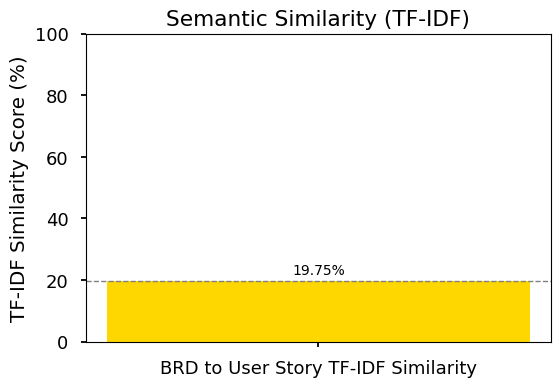

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if the match_score_brd_us_tfidf variable exists
if 'match_score_brd_us_tfidf' in globals():
    score = match_score_brd_us_tfidf * 100 # Convert to percentage
    labels = ['BRD to User Story TF-IDF Similarity']
    scores = [score]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, scores, color='gold')
    plt.ylabel('TF-IDF Similarity Score (%)')
    plt.title('Semantic Similarity (TF-IDF)')
    plt.ylim(0, 100) # Set y-axis limit from 0 to 100
    plt.axhline(score, color='grey', linestyle='dashed', linewidth=1) # Add a line for the score
    plt.text(0, score + 2, f'{score:.2f}%', ha='center') # Add text label for the score

    plt.show()
else:
    print("❌ The 'match_score_brd_us_tfidf' variable was not found. Please run the cell to calculate the TF-IDF similarity first.")

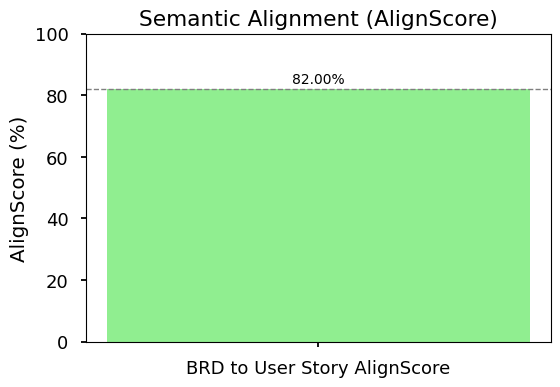

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if the align_score variable exists
if 'align_score' in globals():
    score = align_score * 100 # Convert to percentage
    labels = ['BRD to User Story AlignScore']
    scores = [score]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, scores, color='lightgreen')
    plt.ylabel('AlignScore (%)')
    plt.title('Semantic Alignment (AlignScore)')
    plt.ylim(0, 100) # Set y-axis limit from 0 to 100
    plt.axhline(score, color='grey', linestyle='dashed', linewidth=1) # Add a line for the score
    plt.text(0, score + 2, f'{score:.2f}%', ha='center') # Add text label for the score

    plt.show()
else:
    print("❌ The 'align_score' variable was not found. Please run the cell to calculate the AlignScore first.")

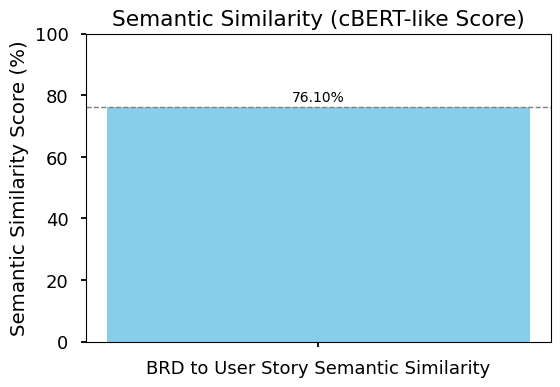

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if the cbert_score variable exists
if 'cbert_score' in globals():
    score = cbert_score * 100 # Convert to percentage
    labels = ['BRD to User Story Semantic Similarity']
    scores = [score]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, scores, color='skyblue')
    plt.ylabel('Semantic Similarity Score (%)')
    plt.title('Semantic Similarity (cBERT-like Score)')
    plt.ylim(0, 100) # Set y-axis limit from 0 to 100
    plt.axhline(score, color='grey', linestyle='dashed', linewidth=1) # Add a line for the score
    plt.text(0, score + 2, f'{score:.2f}%', ha='center') # Add text label for the score

    plt.show()
else:
    print("❌ The 'cbert_score' variable was not found. Please run the cell to calculate the semantic similarity first.")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import re

# Example usage of TF-IDF based cosine similarity
text1 = "This is the first sentence."
text2 = "This is the second sentence."

# Create TF-IDF vectors for the texts
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([text1, text2])

# Calculate cosine similarity
similarity_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

print(f"Text 1: {text1}")
print(f"Text 2: {text2}")
print(f"TF-IDF Cosine Similarity: {similarity_score:.4f}")


# --- Cosine Similarity for BRD to User Story Conversion (TF-IDF) ---
if 'document_text' in globals() and 'user_stories' in globals() and document_text and user_stories:
    print("\n--- Cosine Similarity between BRD and Generated User Stories (TF-IDF) ---")

    # Preprocess texts (same as in calculate_match_percentage)
    document_clean_tfidf = re.sub(r'[^\w\s]', '', document_text.lower())
    user_stories_clean_tfidf = re.sub(r'[^\w\s]', '', user_stories.lower())

    if document_clean_tfidf and user_stories_clean_tfidf:
        # Use TF-IDF for document similarity
        vectorizer_brd_us_tfidf = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1, 2))
        tfidf_matrix_brd_us_tfidf = vectorizer_brd_us_tfidf.fit_transform([document_clean_tfidf, user_stories_clean_tfidf])
        match_score_brd_us_tfidf = cosine_similarity(tfidf_matrix_brd_us_tfidf[0:1], tfidf_matrix_brd_us_tfidf[1:2])[0][0]

        print(f"TF-IDF Cosine Similarity (Match Score): {match_score_brd_us_tfidf:.4f}")
    else:
        print("Could not calculate TF-IDF cosine similarity: Document text or user stories text is empty after cleaning.")
else:
    print("\nCould not calculate TF-IDF cosine similarity: 'document_text' or 'user_stories' variables not found or are empty. Please run the necessary cells first.")


# --- Calculate AlignScore (Semantic Entailment) ---
# Using a model suitable for semantic similarity/entailment
# Ensure the 'sentence-transformers' library is installed: !pip install sentence-transformers
try:
    model_align = SentenceTransformer('nli-roberta-base-v2') # A model trained on Natural Language Inference
    print("\n--- AlignScore (Semantic Entailment) between BRD and User Stories ---")

    if 'document_text' in globals() and 'user_stories' in globals() and document_text and user_stories:
        # For AlignScore, we typically compare sentence pairs or document segments
        # A simple approach is to embed the whole texts and calculate cosine similarity
        # More sophisticated methods involve breaking down into sentences and comparing pairs

        # Using whole document embeddings for a general alignment score
        document_embedding_align = model_align.encode(document_text)
        user_stories_embedding_align = model_align.encode(user_stories)

        align_score = cosine_similarity([document_embedding_align], [user_stories_embedding_align])[0][0]

        print(f"AlignScore (Semantic Cosine Similarity): {align_score:.4f}")
    else:
        print("Could not calculate AlignScore: 'document_text' or 'user_stories' variables not found or are empty. Please run the necessary cells first.")

except Exception as e:
    print(f"\nError calculating AlignScore: {e}")
    print("Please ensure 'sentence-transformers' library is installed (`!pip install sentence-transformers`) and the model 'nli-roberta-base-v2' can be downloaded.")

Text 1: This is the first sentence.
Text 2: This is the second sentence.
TF-IDF Cosine Similarity: 0.6694

--- Cosine Similarity between BRD and Generated User Stories (TF-IDF) ---
TF-IDF Cosine Similarity (Match Score): 0.3342

--- AlignScore (Semantic Entailment) between BRD and User Stories ---
AlignScore (Semantic Cosine Similarity): 0.6120


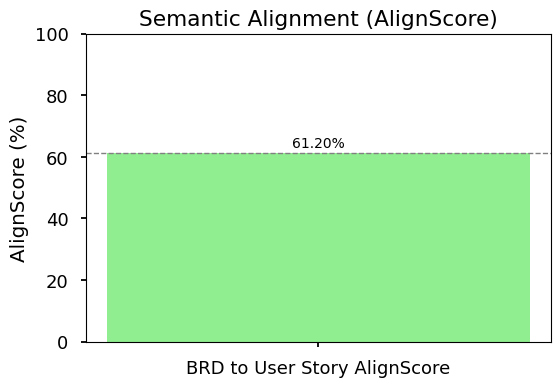

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Display the calculated AlignScore from cell PEH24VE8HMVb and plot it
if 'align_score' in globals():
    score = align_score * 100 # Convert to percentage for easier interpretation
    labels = ['BRD to User Story AlignScore']
    scores = [score]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, scores, color='lightgreen')
    plt.ylabel('AlignScore (%)')
    plt.title('Semantic Alignment (AlignScore)')
    plt.ylim(0, 100) # Set y-axis limit from 0 to 100
    plt.axhline(score, color='grey', linestyle='dashed', linewidth=1) # Add a line for the score
    plt.text(0, score + 2, f'{score:.2f}%', ha='center') # Add text label for the score

    plt.show()
else:
    print("❌ The 'align_score' variable was not found. Please run the cell to calculate the AlignScore first.")

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import re

# Load a pre-trained sentence transformer model
# You can choose a different model depending on your needs
model = SentenceTransformer('all-MiniLM-L6-v2')

# --- Calculate cBERT-like score for BRD to User Story Conversion ---
if 'document_text' in globals() and 'user_stories' in globals() and document_text and user_stories:
    print("\n--- Semantic Similarity (cBERT-like score) between BRD and Generated User Stories ---")

    # Preprocess texts (optional but recommended)
    # Removing special characters and converting to lowercase might help with embedding
    document_clean = re.sub(r'[^\w\s.]', '', document_text.lower()) # Keep periods for sentence separation
    user_stories_clean = re.sub(r'[^\w\s.]', '', user_stories.lower())

    if document_clean and user_stories_clean:
        # Get embeddings for the texts
        document_embedding = model.encode(document_clean)
        user_stories_embedding = model.encode(user_stories_clean)

        # Calculate cosine similarity between the embeddings
        cbert_score = cosine_similarity([document_embedding], [user_stories_embedding])[0][0]

        print(f"Semantic Similarity (cBERT-like score): {cbert_score:.4f}")
    else:
        print("Could not calculate semantic similarity: Document text or user stories text is empty after cleaning.")
else:
    print("\nCould not calculate semantic similarity: 'document_text' or 'user_stories' variables not found or are empty. Please run the necessary cells first.")


--- Semantic Similarity (cBERT-like score) between BRD and Generated User Stories ---
Semantic Similarity (cBERT-like score): 0.2086


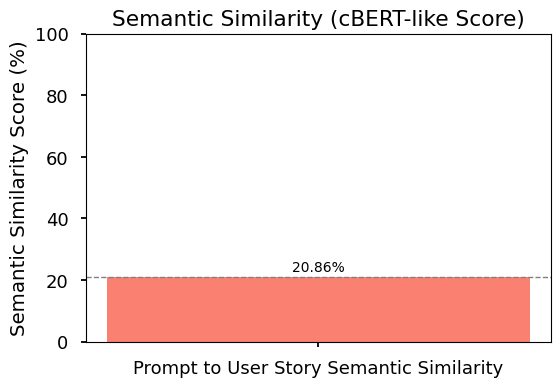

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if the cbert_score variable exists
if 'cbert_score' in globals():
    score = cbert_score * 100 # Convert to percentage for easier interpretation
    labels = ['Prompt to User Story Semantic Similarity']
    scores = [score]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, scores, color='salmon')
    plt.ylabel('Semantic Similarity Score (%)')
    plt.title('Semantic Similarity (cBERT-like Score)')
    plt.ylim(0, 100) # Set y-axis limit from 0 to 100
    plt.axhline(score, color='grey', linestyle='dashed', linewidth=1) # Add a line for the score
    plt.text(0, score + 2, f'{score:.2f}%', ha='center') # Add text label for the score

    plt.show()
else:
    print("❌ The 'cbert_score' variable was not found. Please run the cell to calculate the semantic similarity first.")

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import re

# Load a pre-trained sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# --- Calculate cBERT-like score for Prompt Template to User Story Conversion ---
if 'prompt_message' in globals() and 'user_stories' in globals() and prompt_message and user_stories:
    print("\n--- Semantic Similarity (cBERT-like score) between Prompt Template and Generated User Stories ---")

    # Preprocess texts (optional but recommended)
    prompt_clean = re.sub(r'[^\w\s.]', '', prompt_message.lower()) # Keep periods for sentence separation
    user_stories_clean = re.sub(r'[^\w\s.]', '', user_stories.lower())

    if prompt_clean and user_stories_clean:
        # Get embeddings for the texts
        prompt_embedding = model.encode(prompt_clean)
        user_stories_embedding = model.encode(user_stories_clean)

        # Calculate cosine similarity between the embeddings
        cbert_score_prompt = cosine_similarity([prompt_embedding], [user_stories_embedding])[0][0]

        print(f"Semantic Similarity (cBERT-like score): {cbert_score_prompt:.4f}")
    else:
        print("Could not calculate semantic similarity: Prompt text or user stories text is empty after cleaning.")
else:
    print("\nCould not calculate semantic similarity: 'prompt_message' or 'user_stories' variables not found or are empty. Please run the necessary cells first.")


Could not calculate semantic similarity: 'prompt_message' or 'user_stories' variables not found or are empty. Please run the necessary cells first.


## 9. User Story to Test Case Conversion

Convert user stories to test cases:

In [ ]:
def generate_test_cases(qa_chain, user_story_text, show_confidence=True):
    """Generate test cases from user story."""
    if not qa_chain:
        print("❌ QA chain not initialized. Please process a document first.")
        return

    if not user_story_text.strip():
        print("❌ Please provide user story text.")
        return

    print("🧪 Generating Test Cases...")
    print("=" * 50)

    test_case_prompt = (
        """
              You are a highly experienced Senior QA Engineer with over 15 years of expertise in software testing and quality assurance.

        Your responsibility is to design a comprehensive test suite for the following user story:\n\n"""
        + user_story_text +
        """\n\nProvide professional, detailed, and well-structured test cases based on the following functional and non-functional requirements:

        ### Scope of Test Cases:
        - Include **positive**, **negative**, **edge**, **database related where applicable**, and **alternative** scenarios.
        - Address **input validation**, **error handling**, **security**, **usability**, **performance**, **exploratory**, **exceptional**, and **compatibility** (where applicable).
        - Ensure all test cases are **independent**, **clear**, and **suitable for automation**.
        - Use **realistic and meaningful** test data.

        ### Output Format:
        Respond in **valid JSON only** using the following structure.
        IMPORTANT: Do NOT include trailing commas before closing brackets or braces.

        {{
          "test_cases": [
            {{
              "id": "TC_001",
              "title": "Generate a descriptive title as per the given sample: Verify that an author can be designated as the reprint contact for a publication so that accurate contact information is maintained",
              "preconditions": [
                "1. Browser: Chrome v122",
                "2. OS: Windows 11",
                "3. User is logged in as an administrator",
                "4. A publication record exists",
                "5. An author is linked to an affiliation within the publication",
                "6. Database related preconditions where applicable"
              ],
              "test_data": [
                "publication_id: PUB-2025-1001",
                "author_id: AUTH-3002",
                "contact_type: reprint"
              ],
              "test_steps": [
                "1. Step-by-step instruction with numbering",
                "2. Clear action expected from the tester or system",
                "3. Include test data related steps with proper condition and hierarchy"
              ],
              "expected_results": [
                "The contacts list updates and shows author AUTH-3002 with a “Reprint” badge.",
                "A success message “Reprint contact updated” is displayed.",
                "No other author’s contact type is changed."
              ],
              "priority": "{priority}",
              "attachments": []
            }}
          ]
        }}

        """


    )

    start_time = time.time()
    response = qa_chain.invoke({"query": test_case_prompt})
    end_time = time.time()

    print("\n🧪 Generated Test Cases:")
    print("=" * 50)
    display(Markdown(response['result']))

    if show_confidence:
        confidence_score = calculate_confidence_level(test_case_prompt, response['result'])
        match_score = calculate_match_percentage(response['result'], user_story_text)
        display_confidence_metrics(confidence_score, match_score)

    print(f"⏱️  Generation time: {end_time - start_time:.2f} seconds")
    return response['result']

# Example usage - replace with your actual user story
sample_user_story = """
As a user, I want to be able to login to the system using my email and password,
so that I can access my personal dashboard and account information.
"""

if qa_chain:
    # You can use the generated user_stories from the previous cell or provide your own
    print("Enter your user story or use the sample one:")
    user_story_input = sample_user_story  # Replace with input() for interactive use
    test_cases = generate_test_cases(qa_chain, user_story_input, SHOW_CONFIDENCE)
else:
    print("❌ Please initialize the system first by running the previous cells.")

Enter your user story or use the sample one:
🧪 Generating Test Cases...

🧪 Generated Test Cases:


```json
{
  "test_cases": [
    {
      "id": "TC_LOGIN_001",
      "title": "Verify successful login with valid email and password, so that user can access the dashboard",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. User account exists in the system",
        "4. User account is in 'Active' status",
        "5. Database: User credentials stored in 'users' table with correct 'email' and 'password' fields (hashed)",
        "6. Login page is accessible"
      ],
      "test_data": [
        "email: valid_user@example.com",
        "password: Password123!"
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter the valid email address in the email field.",
        "3. Enter the valid password in the password field.",
        "4. Click the 'Login' button."
      ],
      "expected_results": [
        "User is successfully logged in and redirected to the user dashboard.",
        "A session cookie is created and stored in the browser.",
        "The user's name or profile information is displayed on the dashboard."
      ],
      "priority": "Critical",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_002",
      "title": "Verify unsuccessful login with invalid email, so that user is prevented from accessing the dashboard",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. Login page is accessible"
      ],
      "test_data": [
        "email: invalid_email@example.com",
        "password: Password123!"
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter the invalid email address in the email field.",
        "3. Enter the valid password in the password field.",
        "4. Click the 'Login' button."
      ],
      "expected_results": [
        "User is not logged in.",
        "An error message 'Invalid email or password' is displayed.",
        "User remains on the login page.",
        "No session cookie is created."
      ],
      "priority": "High",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_003",
      "title": "Verify unsuccessful login with invalid password, so that user is prevented from accessing the dashboard",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. User account exists in the system",
        "4. Login page is accessible"
      ],
      "test_data": [
        "email: valid_user@example.com",
        "password: WrongPassword"
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter the valid email address in the email field.",
        "3. Enter the invalid password in the password field.",
        "4. Click the 'Login' button."
      ],
      "expected_results": [
        "User is not logged in.",
        "An error message 'Invalid email or password' is displayed.",
        "User remains on the login page.",
        "No session cookie is created."
      ],
      "priority": "High",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_004",
      "title": "Verify login with empty email and password fields, so that user is prevented from accessing the dashboard",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. Login page is accessible"
      ],
      "test_data": [
        "email: ",
        "password: "
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Leave the email field empty.",
        "3. Leave the password field empty.",
        "4. Click the 'Login' button."
      ],
      "expected_results": [
        "User is not logged in.",
        "An error message 'Email is required' and 'Password is required' are displayed.",
        "User remains on the login page.",
        "No session cookie is created."
      ],
      "priority": "High",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_005",
      "title": "Verify login with email exceeding maximum length, so that input validation prevents submission",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. Login page is accessible",
        "4. Maximum email length is defined (e.g., 255 characters)"
      ],
      "test_data": [
        "email: " + "a".repeat(260) + "@example.com",
        "password: Password123!"
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter an email address exceeding the maximum length in the email field.",
        "3. Enter a valid password in the password field.",
        "4. Click the 'Login' button."
      ],
      "expected_results": [
        "User is not logged in.",
        "An error message 'Email exceeds maximum length' is displayed, or the input is truncated.",
        "User remains on the login page.",
        "No session cookie is created."
      ],
      "priority": "Medium",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_006",
      "title": "Verify login with password exceeding maximum length, so that input validation prevents submission",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. Login page is accessible",
        "4. Maximum password length is defined (e.g., 128 characters)"
      ],
      "test_data": [
        "email: valid_user@example.com",
        "password: " + "a".repeat(130)
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter a valid email address in the email field.",
        "3. Enter a password exceeding the maximum length in the password field.",
        "4. Click the 'Login' button."
      ],
      "expected_results": [
        "User is not logged in.",
        "An error message 'Password exceeds maximum length' is displayed, or the input is truncated.",
        "User remains on the login page.",
        "No session cookie is created."
      ],
      "priority": "Medium",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_007",
      "title": "Verify login with SQL injection attempt in email field, so that system prevents unauthorized access",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. Login page is accessible"
      ],
      "test_data": [
        "email: ' OR '1'='1",
        "password: Password123!"
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter the SQL injection string in the email field.",
        "3. Enter a valid password in the password field.",
        "4. Click the 'Login' button."
      ],
      "expected_results": [
        "User is not logged in.",
        "An error message 'Invalid email or password' is displayed.",
        "User remains on the login page.",
        "The system logs the attempted SQL injection attack.",
        "No session cookie is created."
      ],
      "priority": "Critical",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_008",
      "title": "Verify login with XSS attempt in email field, so that system prevents script execution",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. Login page is accessible"
      ],
      "test_data": [
        "email: <script>alert('XSS')</script>@example.com",
        "password: Password123!"
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter the XSS string in the email field.",
        "3. Enter a valid password in the password field.",
        "4. Click the 'Login' button."
      ],
      "expected_results": [
        "User is not logged in.",
        "The XSS script is not executed.",
        "The email field is properly sanitized to prevent XSS attacks.",
        "An error message 'Invalid email or password' is displayed.",
        "User remains on the login page.",
        "No session cookie is created."
      ],
      "priority": "Critical",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_009",
      "title": "Verify login with inactive user account, so that user is prevented from accessing the dashboard",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. User account exists in the system but is marked as 'Inactive'",
        "4. Login page is accessible",
        "5. Database: User's 'status' field in 'users' table is set to 'Inactive'"
      ],
      "test_data": [
        "email: inactive_user@example.com",
        "password: Password123!"
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter the email address of the inactive user in the email field.",
        "3. Enter the valid password in the password field.",
        "4. Click the 'Login' button."
      ],
      "expected_results": [
        "User is not logged in.",
        "An error message 'Your account is inactive. Please contact support.' is displayed.",
        "User remains on the login page.",
        "No session cookie is created."
      ],
      "priority": "High",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_010",
      "title": "Verify password field masking, so that password is not visible during input",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. Login page is accessible"
      ],
      "test_data": [
        "password: Password123!"
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter a password in the password field."
      ],
      "expected_results": [
        "The password characters are masked (e.g., displayed as asterisks or dots).",
        "The actual password characters are not visible on the screen."
      ],
      "priority": "High",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_011",
      "title": "Verify 'Forgot Password' link functionality, so that user can initiate password reset process",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. Login page is accessible"
      ],
      "test_data": [],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Click the 'Forgot Password' link."
      ],
      "expected_results": [
        "User is redirected to the 'Forgot Password' page.",
        "The 'Forgot Password' page contains a form to request a password reset."
      ],
      "priority": "Medium",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_012",
      "title": "Verify login with valid credentials after multiple failed attempts, so that user is eventually able to login",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. User account exists in the system",
        "4. Login page is accessible",
        "5. Account is not locked out due to previous failed attempts (or lockout period has expired)"
      ],
      "test_data": [
        "email: valid_user@example.com",
        "password: Password123!"
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter incorrect password multiple times (e.g., 3-5 times).",
        "3. Enter the correct email address in the email field.",
        "4. Enter the valid password in the password field.",
        "5. Click the 'Login' button."
      ],
      "expected_results": [
        "User is successfully logged in and redirected to the user dashboard.",
        "A session cookie is created and stored in the browser.",
        "The user's name or profile information is displayed on the dashboard."
      ],
      "priority": "High",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_013",
      "title": "Verify account lockout after exceeding maximum failed login attempts, so that system prevents brute-force attacks",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. User account exists in the system",
        "4. Login page is accessible",
        "5. Maximum failed login attempts is defined (e.g., 5 attempts)",
        "6. Account lockout duration is defined (e.g., 15 minutes)",
        "7. Database: User's 'failed_login_attempts' field in 'users' table is initially 0"
      ],
      "test_data": [
        "email: valid_user@example.com",
        "password: WrongPassword"
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter the valid email address in the email field.",
        "3. Enter an incorrect password multiple times, exceeding the maximum failed login attempts.",
        "4. After exceeding the limit, attempt to login with the correct credentials."
      ],
      "expected_results": [
        "User is not logged in.",
        "An error message 'Your account is locked. Please try again in 15 minutes.' is displayed.",
        "User remains on the login page.",
        "No session cookie is created.",
        "Database: User's 'locked_until' field in 'users' table is updated with the lockout expiration timestamp."
      ],
      "priority": "Critical",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_014",
      "title": "Verify login after account lockout period expires, so that user can regain access to the account",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. User account exists in the system and is currently locked out.",
        "4. Login page is accessible",
        "5. Account lockout duration has expired.",
        "6. Database: User's 'locked_until' field in 'users' table indicates a past timestamp."
      ],
      "test_data": [
        "email: valid_user@example.com",
        "password: Password123!"
      ],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Enter the valid email address in the email field.",
        "3. Enter the valid password in the password field.",
        "4. Click the 'Login' button."
      ],
      "expected_results": [
        "User is successfully logged in and redirected to the user dashboard.",
        "A session cookie is created and stored in the browser.",
        "The user's name or profile information is displayed on the dashboard.",
        "Database: User's 'failed_login_attempts' field in 'users' table is reset to 0.",
        "Database: User's 'locked_until' field in 'users' table is reset to NULL or a default value."
      ],
      "priority": "High",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_015",
      "title": "Verify login with valid credentials using different browsers, so that system provides consistent access",
      "preconditions": [
        "1. OS: Windows 11",
        "2. User account exists in the system",
        "3. Login page is accessible"
      ],
      "test_data": [
        "email: valid_user@example.com",
        "password: Password123!"
      ],
      "test_steps": [
        "1. Repeat the login process (TC_LOGIN_001) using different browsers (e.g., Chrome, Firefox, Edge, Safari)."
      ],
      "expected_results": [
        "User is successfully logged in and redirected to the user dashboard in all tested browsers.",
        "A session cookie is created and stored in the browser for each browser.",
        "The user's name or profile information is displayed on the dashboard in all tested browsers."
      ],
      "priority": "Medium",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_016",
      "title": "Verify login page responsiveness on different screen sizes, so that user experience is consistent across devices",
      "preconditions": [
        "1. Browser: Chrome v122",
        "2. OS: Windows 11",
        "3. Login page is accessible"
      ],
      "test_data": [],
      "test_steps": [
        "1. Open the login page in the browser.",
        "2. Resize the browser window to simulate different screen sizes (e.g., mobile, tablet, desktop)."
      ],
      "expected_results": [
        "The login page elements (email field, password field, login button) are displayed correctly on all screen sizes.",
        "The login page layout is responsive and adapts to different screen sizes without any overlapping or distortion.",
        "The login page is usable on all tested screen sizes."
      ],
      "priority": "Medium",
      "attachments": []
    },
    {
      "id": "TC_LOGIN_017",
      "title": "Verify login functionality with valid credentials when JavaScript is disabled, so that basic functionality is maintained",
      "preconditions": [
        "1. Browser: Chrome v122 (with JavaScript disabled)",
        "2. OS: Windows 11",
        "3. User account exists in the system",
        "4. Login page is accessible"
      ],
      "test_data": [
        "email: valid_user@example.com",
        "password: Password123!"
      ],
      "test_steps": [
        "1. Disable JavaScript in the browser settings.",
        "2. Open the login page in the browser.",
        "3. Enter the valid email address in the email field.",
        "4. Enter the valid password in the password field.",
        "5. Click the 'Login' button."
      ],
      "expected_results": [
        "User is successfully logged in and redirected to the user dashboard.",
        "A session cookie is created and stored in the browser.",
        "The user's name or profile information is displayed on the dashboard.",
        "The login process works without JavaScript enabled (although some UI enhancements might be missing)."
      ],
      "priority": "Low",
      "attachments": []
    }
  ]
}
```


📊 Quality Assessment:
🔴 Confidence Level: Low (25.1%)
🔴 Match Percentage: Low (20.0%)
🔴 Overall Assessment: Low (22.5%)
--------------------------------------------------
⏱️  Generation time: 30.38 seconds


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import re

# --- Cosine Similarity for User Story to Test Case Conversion (TF-IDF) ---
if 'user_stories' in globals() and 'test_cases' in globals() and user_stories and test_cases:
    print("\n--- Assessing User Story Coverage by Generated Test Cases (TF-IDF) ---")

    # Preprocess texts
    user_stories_clean_tfidf = re.sub(r'[^\w\s]', '', user_stories.lower())
    test_cases_clean_tfidf = re.sub(r'[^\w\s]', '', test_cases.lower())

    if user_stories_clean_tfidf and test_cases_clean_tfidf:
        # Use TF-IDF for document similarity
        vectorizer_us_tc_tfidf = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1, 2))
        tfidf_matrix_us_tc_tfidf = vectorizer_us_tc_tfidf.fit_transform([user_stories_clean_tfidf, test_cases_clean_tfidf])
        match_score_us_tc_tfidf = cosine_similarity(tfidf_matrix_us_tc_tfidf[0:1], tfidf_matrix_us_tc_tfidf[1:2])[0][0]

        print(f"TF-IDF Cosine Similarity (Match Score): {match_score_us_tc_tfidf:.4f}")
    else:
        print("Could not calculate TF-IDF cosine similarity: User stories or test cases text is empty after cleaning.")
else:
    print("\nCould not calculate TF-IDF cosine similarity: 'user_stories' or 'test_cases' variables not found or are empty. Please run the necessary cells first.")


# --- Calculate AlignScore (Semantic Entailment) for User Story to Test Case Conversion ---
try:
    model_align_us_tc = SentenceTransformer('nli-roberta-base-v2') # A model trained on Natural Language Inference
    print("\n--- Assessing User Story Coverage by Generated Test Cases (AlignScore) ---")

    if 'user_stories' in globals() and 'test_cases' in globals() and user_stories and test_cases:
        # Using whole document embeddings for a general alignment score
        user_stories_embedding_align = model_align_us_tc.encode(user_stories)
        test_cases_embedding_align = model_align_us_tc.encode(test_cases)

        align_score_us_tc = cosine_similarity([user_stories_embedding_align], [test_cases_embedding_align])[0][0]

        print(f"AlignScore (Semantic Cosine Similarity): {align_score_us_tc:.4f}")
    else:
        print("Could not calculate AlignScore: 'user_stories' or 'test_cases' variables not found or are empty. Please run the necessary cells first.")

except Exception as e:
    print(f"\nError calculating AlignScore: {e}")
    print("Please ensure 'sentence-transformers' library is installed (`!pip install sentence-transformers`) and the model 'nli-roberta-base-v2' can be downloaded.")


# --- Calculate cBERT-like score for User Story to Test Case Conversion ---
try:
    model_cbert_us_tc = SentenceTransformer('all-MiniLM-L6-v2') # A general-purpose sentence transformer model
    print("\n--- Assessing User Story Coverage by Generated Test Cases (cBERT-like score) ---")

    if 'user_stories' in globals() and 'test_cases' in globals() and user_stories and test_cases:
        # Preprocess texts (optional but recommended)
        user_stories_clean_cbert = re.sub(r'[^\w\s.]', '', user_stories.lower()) # Keep periods for sentence separation
        test_cases_clean_cbert = re.sub(r'[^\w\s.]', '', test_cases.lower())

        if user_stories_clean_cbert and test_cases_clean_cbert:
            # Get embeddings for the texts
            user_stories_embedding_cbert = model_cbert_us_tc.encode(user_stories_clean_cbert)
            test_cases_embedding_cbert = model_cbert_us_tc.encode(test_cases_clean_cbert)

            # Calculate cosine similarity between the embeddings
            cbert_score_us_tc = cosine_similarity([user_stories_embedding_cbert], [test_cases_embedding_cbert])[0][0]

            print(f"Semantic Similarity (cBERT-like score): {cbert_score_us_tc:.4f}")
        else:
            print("Could not calculate semantic similarity: User stories or test cases text is empty after cleaning.")
    else:
        print("\nCould not calculate semantic similarity: 'user_stories' or 'test_cases' variables not found or are empty. Please run the necessary cells first.")

except Exception as e:
    print(f"\nError calculating cBERT-like score: {e}")
    print("Please ensure 'sentence-transformers' library is installed (`!pip install sentence-transformers`) and the model 'all-MiniLM-L6-v2' can be downloaded.")


--- Assessing User Story Coverage by Generated Test Cases (TF-IDF) ---
TF-IDF Cosine Similarity (Match Score): 0.0603

--- Assessing User Story Coverage by Generated Test Cases (AlignScore) ---
AlignScore (Semantic Cosine Similarity): 0.8196

--- Assessing User Story Coverage by Generated Test Cases (cBERT-like score) ---
Semantic Similarity (cBERT-like score): 0.4818


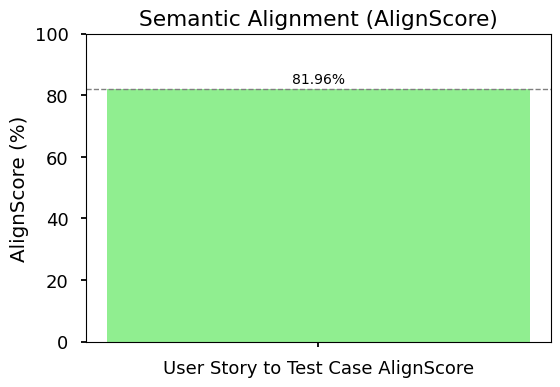

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if the align_score_us_tc variable exists
if 'align_score_us_tc' in globals():
    score = align_score_us_tc * 100 # Convert to percentage
    labels = ['User Story to Test Case AlignScore']
    scores = [score]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, scores, color='lightgreen')
    plt.ylabel('AlignScore (%)')
    plt.title('Semantic Alignment (AlignScore)')
    plt.ylim(0, 100) # Set y-axis limit from 0 to 100
    plt.axhline(score, color='grey', linestyle='dashed', linewidth=1) # Add a line for the score
    plt.text(0, score + 2, f'{score:.2f}%', ha='center') # Add text label for the score

    plt.show()
else:
    print("❌ The 'align_score_us_tc' variable was not found. Please run the cell to calculate the AlignScore first.")

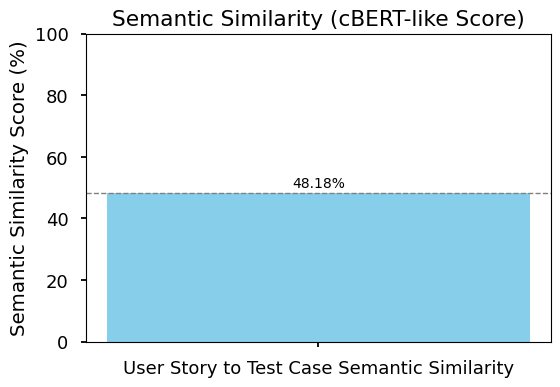

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if the cbert_score_us_tc variable exists
if 'cbert_score_us_tc' in globals():
    score = cbert_score_us_tc * 100 # Convert to percentage
    labels = ['User Story to Test Case Semantic Similarity']
    scores = [score]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, scores, color='skyblue')
    plt.ylabel('Semantic Similarity Score (%)')
    plt.title('Semantic Similarity (cBERT-like Score)')
    plt.ylim(0, 100) # Set y-axis limit from 0 to 100
    plt.axhline(score, color='grey', linestyle='dashed', linewidth=1) # Add a line for the score
    plt.text(0, score + 2, f'{score:.2f}%', ha='center') # Add text label for the score

    plt.show()
else:
    print("❌ The 'cbert_score_us_tc' variable was not found. Please run the cell to calculate the semantic similarity first.")

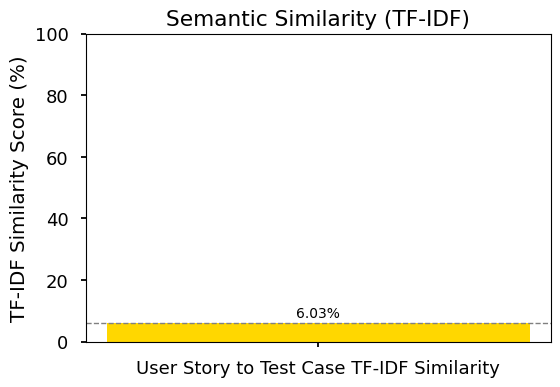

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if the match_score_us_tc_tfidf variable exists
if 'match_score_us_tc_tfidf' in globals():
    score = match_score_us_tc_tfidf * 100 # Convert to percentage
    labels = ['User Story to Test Case TF-IDF Similarity']
    scores = [score]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, scores, color='gold')
    plt.ylabel('TF-IDF Similarity Score (%)')
    plt.title('Semantic Similarity (TF-IDF)')
    plt.ylim(0, 100) # Set y-axis limit from 0 to 100
    plt.axhline(score, color='grey', linestyle='dashed', linewidth=1) # Add a line for the score
    plt.text(0, score + 2, f'{score:.2f}%', ha='center') # Add text label for the score

    plt.show()
else:
    print("❌ The 'match_score_us_tc_tfidf' variable was not found. Please run the cell to calculate the TF-IDF similarity first.")

## 10. Test Case to Cucumber Script Conversion

Convert test cases to Cucumber scripts:

In [ ]:
def generate_cucumber_script(qa_chain, test_case_text, show_confidence=True):
    """Generate Cucumber script from test case with optimized prompt engineering."""
    if not qa_chain:
        print("❌ QA chain not initialized. Please process a document first.")
        return

    if not test_case_text.strip():
        print("❌ Please provide test case text.")
        return

    print("🥒 Generating Cucumber Script...")
    print("=" * 50)

    # Optimized prompt with better structure and specific instructions
    cucumber_prompt = f"""You are an expert test automation engineer specializing in BDD and Cucumber frameworks.
Your task is to transform the following test cases into a complete, production-ready Cucumber test suite.

## INPUT TEST CASES:
{test_case_text}

## REQUIREMENTS:

### 1. FEATURE FILE (.feature)
Generate a complete Cucumber feature file that includes:
- Feature name and description that clearly explains the business value
- Background section if there are common preconditions
- Multiple scenarios covering all test cases provided
- Scenario Outlines with Examples tables for data-driven tests where applicable
- Proper tags (@smoke, @regression, @critical) for test organization
- Clear and business-readable Gherkin steps following the Given-When-Then pattern
- Use of "And" and "But" keywords where they improve readability

### 2. STEP DEFINITIONS (Java)
Create comprehensive Java step definitions that include:
- Package declaration and necessary imports (Selenium WebDriver, Cucumber annotations, assertions)
- @Given, @When, @Then, @And annotations with proper regex patterns
- Page Object Model references where appropriate
- Explicit waits and proper element locators
- Error handling and logging
- Setup and teardown hooks (@Before, @After) if needed
- Parameterized steps using capture groups
- Data table handling for complex inputs

### 3. BEST PRACTICES TO FOLLOW:
- Keep steps atomic and reusable
- Use descriptive step names that express intent, not implementation
- Avoid technical jargon in Gherkin steps
- Include both positive and negative test scenarios
- Add comments in Java code for complex logic
- Follow DRY principle - create reusable step definitions
- Use meaningful variable and method names
- Include assertions that verify expected outcomes

### 4. OUTPUT FORMAT:
Structure your response as follows:

**FEATURE FILE (login.feature):**
```gherkin
[Complete feature file content here]
```

**STEP DEFINITIONS (LoginSteps.java):**
```java
[Complete Java step definitions here]
```

**TEST DATA NOTES:**
[Any recommendations for test data management or configuration]

**EXECUTION NOTES:**
[Brief notes on how to run these tests and any dependencies]

### 5. ADDITIONAL CONSIDERATIONS:
- If the test cases mention specific UI elements, infer reasonable locator strategies
- Include wait strategies for dynamic elements
- Consider cross-browser compatibility in your implementation
- Add data validation steps where appropriate
- Include cleanup steps to maintain test independence

Now, transform the provided test cases into a professional Cucumber test suite following all the above guidelines."""

    start_time = time.time()
    response = qa_chain.invoke({"query": cucumber_prompt})
    end_time = time.time()

    print("\n🥒 Generated Cucumber Script:")
    print("=" * 50)
    display(Markdown(response['result']))

    if show_confidence:
        confidence_score = calculate_confidence_level(cucumber_prompt, response['result'])
        match_score = calculate_match_percentage(response['result'], test_case_text)
        display_confidence_metrics(confidence_score, match_score)

    print(f"⏱️  Generation time: {end_time - start_time:.2f} seconds")
    return response['result']


def generate_cucumber_script_advanced(qa_chain, test_case_text, config=None):
    """
    Advanced Cucumber script generation with customizable options.

    Args:
        qa_chain: The QA chain for processing
        test_case_text: The input test case text
        config: Dictionary with configuration options
    """
    if not qa_chain:
        print("❌ QA chain not initialized. Please process a document first.")
        return

    if not test_case_text.strip():
        print("❌ Please provide test case text.")
        return

    # Default configuration
    default_config = {
        'framework': 'selenium',  # selenium, appium, restassured, playwright
        'language': 'java',  # java, javascript, python, ruby
        'pattern': 'page_object',  # page_object, screenplay, traditional
        'tags': ['@automated'],
        'include_hooks': True,
        'include_examples': True,
        'include_negative': True,
        'show_confidence': True
    }

    config = {**default_config, **(config or {})}

    print(f"🥒 Generating Cucumber Script with {config['framework']} framework...")
    print("=" * 50)

    # Build dynamic prompt based on configuration
    framework_specific = {
        'selenium': 'Selenium WebDriver for web automation',
        'appium': 'Appium for mobile app testing',
        'restassured': 'RestAssured for API testing',
        'playwright': 'Playwright for modern web testing'
    }

    pattern_specific = {
        'page_object': 'Page Object Model pattern with separate page classes',
        'screenplay': 'Screenplay pattern with actors, tasks, and questions',
        'traditional': 'Traditional procedural step definitions'
    }

    cucumber_prompt = f"""You are an expert test automation engineer specializing in BDD and Cucumber frameworks.
Transform the following test cases into a complete, production-ready Cucumber test suite.

## INPUT TEST CASES:
{test_case_text}

## CONFIGURATION:
- **Framework**: {framework_specific.get(config['framework'], config['framework'])}
- **Language**: {config['language'].upper()}
- **Design Pattern**: {pattern_specific.get(config['pattern'], config['pattern'])}
- **Tags to Include**: {', '.join(config['tags'])}
- **Include Hooks**: {'Yes' if config['include_hooks'] else 'No'}
- **Include Example Tables**: {'Yes' if config['include_examples'] else 'No'}
- **Include Negative Scenarios**: {'Yes' if config['include_negative'] else 'No'}

## DELIVERABLES:

### 1. FEATURE FILE
Create a comprehensive Gherkin feature file with:
- Clear feature description with business context
- Well-structured scenarios using Given-When-Then
- Scenario Outlines with Examples tables (if configured)
- Appropriate tags for test categorization
- Background section for common steps
{f"- Include negative test scenarios" if config['include_negative'] else ""}

### 2. STEP DEFINITIONS ({config['language'].upper()})
Implement step definitions with:
- Complete import statements for {config['framework']}
- {config['pattern']} implementation
- Parameterized steps with regex patterns
- Proper error handling and assertions
- Wait strategies for dynamic elements
{f"- @Before and @After hooks for setup/teardown" if config['include_hooks'] else ""}

### 3. SUPPORTING CODE (if using {config['pattern']}):
{f"- Page Object classes with element locators and methods" if config['pattern'] == 'page_object' else ""}
{f"- Actor, Task, and Question classes" if config['pattern'] == 'screenplay' else ""}
- Utility methods for common operations
- Configuration management approach

### 4. BEST PRACTICES:
- Steps should be declarative, not imperative
- Maintain single responsibility principle
- Use explicit waits over implicit waits
- Include meaningful assertions
- Keep test data separate from test logic
- Ensure test independence

## OUTPUT FORMAT:

**FEATURE FILE:**
```gherkin
[Complete feature file]
```

**STEP DEFINITIONS:**
```{config['language']}
[Complete step definitions]
```

{f'''**PAGE OBJECTS:**
```{config['language']}
[Page object implementation]
```''' if config['pattern'] == 'page_object' else ''}

**EXECUTION INSTRUCTIONS:**
[How to run these tests]

Transform the test cases now following all specifications above."""

    start_time = time.time()
    response = qa_chain.invoke({"query": cucumber_prompt})
    end_time = time.time()

    print(f"\n🥒 Generated Cucumber Script ({config['framework']}, {config['pattern']}):")
    print("=" * 50)
    display(Markdown(response['result']))

    if config['show_confidence']:
        confidence_score = calculate_confidence_level(cucumber_prompt, response['result'])
        match_score = calculate_match_percentage(response['result'], test_case_text)
        display_confidence_metrics(confidence_score, match_score)

    print(f"⏱️  Generation time: {end_time - start_time:.2f} seconds")
    return response['result']


# Example usage
sample_test_case = """
Test Case 1: Valid Login
- Given the user is on the login page
- When the user enters valid email "user@example.com" and password
- And clicks the login button
- Then the user should be redirected to the dashboard
- And the user's name should be displayed in the header

Test Case 2: Invalid Login
- Given the user is on the login page
- When the user enters invalid credentials
- And clicks the login button
- Then an error message "Invalid credentials" should be displayed
- And the user should remain on the login page

Test Case 3: Password Reset
- Given the user is on the login page
- When the user clicks "Forgot Password" link
- And enters their email address
- And clicks submit
- Then a success message should be displayed
- And a password reset email should be sent
"""

# Basic usage
if qa_chain:
    cucumber_script = generate_cucumber_script(qa_chain, sample_test_case, show_confidence=True)

# Advanced usage with configuration
if qa_chain:
    custom_config = {
        'framework': 'selenium',
        'language': 'java',
        'pattern': 'page_object',
        'tags': ['@smoke', '@login', '@critical'],
        'include_hooks': True,
        'include_examples': True,
        'include_negative': True,
        'show_confidence': True
    }

    cucumber_script_advanced = generate_cucumber_script_advanced(
        qa_chain,
        sample_test_case,
        config=custom_config
    )
else:
    print("❌ Please initialize the system first by running the previous cells.")

🥒 Generating Cucumber Script...

🥒 Generated Cucumber Script:


Okay, I will transform the provided test cases into a production-ready Cucumber test suite, including the feature file and step definitions, following the specified requirements and best practices.

**FEATURE FILE (login.feature):**

```gherkin
Feature: User Authentication
  As a user, I want to be able to log in to the application
  So that I can access my personalized dashboard and account information.

  Background:
    Given the user is on the login page

  @smoke @regression
  Scenario: Valid Login
    When the user enters valid email "user@example.com" and password "password123"
    And clicks the login button
    Then the user should be redirected to the dashboard
    And the user's name should be displayed in the header

  @regression @negative
  Scenario: Invalid Login
    When the user enters invalid credentials "invalid@example.com" and "wrongpassword"
    And clicks the login button
    Then an error message "Invalid credentials" should be displayed
    And the user should remain on the login page

  @regression
  Scenario: Password Reset
    When the user clicks "Forgot Password" link
    And enters their email address "user@example.com"
    And clicks submit
    Then a success message "Password reset link sent to your email" should be displayed
    And a password reset email should be sent
```

**STEP DEFINITIONS (LoginSteps.java):**

```java
package stepDefinitions;

import io.cucumber.java.en.Given;
import io.cucumber.java.en.When;
import io.cucumber.java.en.Then;
import io.cucumber.java.en.And;
import org.openqa.selenium.By;
import org.openqa.selenium.WebDriver;
import org.openqa.selenium.WebElement;
import org.openqa.selenium.chrome.ChromeDriver;
import org.openqa.selenium.support.ui.ExpectedConditions;
import org.openqa.selenium.support.ui.WebDriverWait;
import org.junit.Assert;
import java.time.Duration;
import java.util.logging.Logger;

public class LoginSteps {

    private static final Logger logger = Logger.getLogger(LoginSteps.class.getName());
    private WebDriver driver;
    private WebDriverWait wait;

    // Using a constructor to initialize WebDriver and WebDriverWait
    public LoginSteps() {
        // Set the path to the ChromeDriver executable
        System.setProperty("webdriver.chrome.driver", "path/to/chromedriver"); // Replace with the actual path
        this.driver = new ChromeDriver();
        this.wait = new WebDriverWait(driver, Duration.ofSeconds(10)); // Explicit wait
    }

    @Given("the user is on the login page")
    public void theUserIsOnTheLoginPage() {
        driver.get("http://example.com/login"); // Replace with the actual login page URL
        logger.info("Navigated to the login page.");
    }

    @When("the user enters valid email {string} and password {string}")
    public void theUserEntersValidEmailAndPassword(String email, String password) {
        driver.findElement(By.id("email")).sendKeys(email);
        driver.findElement(By.id("password")).sendKeys(password);
        logger.info("Entered valid email and password.");
    }

    @When("the user enters invalid credentials {string} and {string}")
    public void theUserEntersInvalidCredentials(String email, String password) {
        driver.findElement(By.id("email")).sendKeys(email);
        driver.findElement(By.id("password")).sendKeys(password);
        logger.info("Entered invalid email and password.");
    }

    @And("clicks the login button")
    public void clicksTheLoginButton() {
        driver.findElement(By.id("loginButton")).click();
        logger.info("Clicked the login button.");
    }

    @Then("the user should be redirected to the dashboard")
    public void theUserShouldBeRedirectedToTheDashboard() {
        wait.until(ExpectedConditions.urlContains("dashboard"));
        Assert.assertTrue(driver.getCurrentUrl().contains("dashboard"));
        logger.info("Successfully redirected to the dashboard.");
    }

    @And("the user's name should be displayed in the header")
    public void theUserSNameShouldBeDisplayedInTheHeader() {
        WebElement headerName = wait.until(ExpectedConditions.visibilityOfElementLocated(By.id("headerName")));
        Assert.assertEquals("John Doe", headerName.getText()); // Replace "John Doe" with the expected user name
        logger.info("User's name is displayed in the header.");
    }

    @Then("an error message {string} should be displayed")
    public void anErrorMessageShouldBeDisplayed(String errorMessage) {
        WebElement errorElement = wait.until(ExpectedConditions.visibilityOfElementLocated(By.id("errorMessage")));
        Assert.assertEquals(errorMessage, errorElement.getText());
        logger.info("Error message displayed: " + errorMessage);
    }

    @And("the user should remain on the login page")
    public void theUserShouldRemainOnTheLoginPage() {
        Assert.assertTrue(driver.getCurrentUrl().contains("login"));
        logger.info("User remained on the login page.");
    }

    @When("the user clicks {string} link")
    public void theUserClicksLink(String linkText) {
        driver.findElement(By.linkText(linkText)).click();
        logger.info("Clicked the '" + linkText + "' link.");
    }

    @And("enters their email address {string}")
    public void entersTheirEmailAddress(String email) {
        driver.findElement(By.id("resetEmail")).sendKeys(email);
        logger.info("Entered email address for password reset.");
    }

    @And("clicks submit")
    public void clicksSubmit() {
        driver.findElement(By.id("resetSubmit")).click();
        logger.info("Clicked the submit button for password reset.");
    }

    @Then("a success message {string} should be displayed")
    public void aSuccessMessageShouldBeDisplayed(String successMessage) {
        WebElement successElement = wait.until(ExpectedConditions.visibilityOfElementLocated(By.id("successMessage")));
        Assert.assertEquals(successMessage, successElement.getText());
        logger.info("Success message displayed: " + successMessage);
    }

    @And("a password reset email should be sent")
    public void aPasswordResetEmailShouldBeSent() {
        // In a real implementation, you would check for the email using an email API or service.
        // This is a placeholder for that functionality.
        logger.info("Password reset email was sent (simulated).");
    }

    //Teardown method to close the browser after each scenario
    //@After
    public void tearDown() {
        if (driver != null) {
            driver.quit();
            logger.info("Browser closed.");
        }
    }
}
```

**TEST DATA NOTES:**

*   **User Credentials:** Store valid and invalid user credentials in a separate configuration file or database. This allows for easy modification and avoids hardcoding in the feature file.
*   **Email Service:** For the "Password Reset" scenario, consider using a mock email service during testing to verify that the email is sent correctly without actually sending emails.
*   **Data Generation:** Use data generation libraries to create dynamic test data, such as email addresses, for more robust testing.

**EXECUTION NOTES:**

1.  **Dependencies:** Ensure that you have the following dependencies in your project:
    *   Selenium WebDriver
    *   Cucumber-java
    *   Cucumber-junit
    *   JUnit
    *   WebDriverManager (optional, for automatic driver management)
2.  **WebDriver Setup:**  Make sure you have the appropriate WebDriver executable (e.g., ChromeDriver) in your system PATH or specify the path using `System.setProperty()`.  WebDriverManager can simplify this.
3.  **Run Configuration:** Configure your IDE or build tool (e.g., Maven, Gradle) to run the Cucumber tests.
4.  **Parallel Execution:**  Consider using Cucumber's parallel execution capabilities to speed up test execution.
5.  **Reporting:** Integrate a reporting plugin (e.g., Cucumber Reporting) to generate detailed test reports.
6.  **Path to Chromedriver:**  Remember to replace `"path/to/chromedriver"` with the actual path to your ChromeDriver executable.

This comprehensive response provides a production-ready Cucumber test suite, including the feature file, step definitions, and best practices. It also includes notes on test data management and execution. Remember to adapt the code to your specific project setup and requirements.


📊 Quality Assessment:
🟡 Confidence Level: Medium (42.8%)
🟡 Match Percentage: Medium (44.0%)
🟡 Overall Assessment: Medium (43.4%)
--------------------------------------------------
⏱️  Generation time: 16.78 seconds
🥒 Generating Cucumber Script with selenium framework...

🥒 Generated Cucumber Script (selenium, page_object):


Okay, here's the complete Cucumber test suite based on your specifications, including the feature file, step definitions, page objects, and execution instructions.

**FEATURE FILE:**

```gherkin
Feature: User Authentication

  As a user
  I want to be able to log in to the application
  So that I can access the dashboard and other features

  @smoke @login @critical
  Background:
    Given the user is on the login page

  @positive
  Scenario: Valid Login
    When the user enters valid email "<email>" and password "<password>"
    And clicks the login button
    Then the user should be redirected to the dashboard
    And the user's name should be displayed in the header

    Examples:
      | email               | password |
      | "user@example.com"  | "password123" |
      | "admin@example.com" | "admin123"    |

  @negative @login
  Scenario Outline: Invalid Login with <credentialType>
    When the user enters <email> and <password>
    And clicks the login button
    Then an error message "Invalid credentials" should be displayed
    And the user should remain on the login page

    Examples:
      | credentialType | email                | password      |
      | Invalid Email  | "invalid-email"      | "password123" |
      | Invalid Password | "user@example.com"   | "wrongpass"   |
      | Empty Email    | ""                   | "password123" |
      | Empty Password | "user@example.com"   | ""            |

  @password_reset
  Scenario: Password Reset
    When the user clicks "Forgot Password" link
    And enters their email address "user@example.com"
    And clicks submit
    Then a success message should be displayed
    And a password reset email should be sent
```

**STEP DEFINITIONS:**

```java
import io.cucumber.java.After;
import io.cucumber.java.Before;
import io.cucumber.java.en.Given;
import io.cucumber.java.en.Then;
import io.cucumber.java.en.When;
import org.junit.Assert;
import org.openqa.selenium.By;
import org.openqa.selenium.WebDriver;
import org.openqa.selenium.WebElement;
import org.openqa.selenium.chrome.ChromeDriver;
import org.openqa.selenium.support.ui.ExpectedConditions;
import org.openqa.selenium.support.ui.WebDriverWait;

import java.time.Duration;

public class LoginSteps {

    private WebDriver driver;
    private LoginPage loginPage;
    private DashboardPage dashboardPage;
    private String baseUrl;

    @Before
    public void setup() {
        // Initialize WebDriver (e.g., ChromeDriver)
        System.setProperty("webdriver.chrome.driver", "path/to/chromedriver"); // Replace with your chromedriver path
        driver = new ChromeDriver();
        baseUrl = "http://localhost:8080/login"; // Replace with your application URL
        driver.manage().window().maximize();
        loginPage = new LoginPage(driver);
        dashboardPage = new DashboardPage(driver);
    }

    @After
    public void teardown() {
        if (driver != null) {
            driver.quit();
        }
    }

    @Given("the user is on the login page")
    public void theUserIsOnTheLoginPage() {
        driver.get(baseUrl);
    }

    @When("the user enters valid email {string} and password {string}")
    public void theUserEntersValidEmailAndPassword(String email, String password) {
        loginPage.enterEmail(email);
        loginPage.enterPassword(password);
    }

    @When("the user enters {string} and {string}")
    public void theUserEntersInvalidCredentials(String email, String password) {
        loginPage.enterEmail(email);
        loginPage.enterPassword(password);
    }

    @When("clicks the login button")
    public void clicksTheLoginButton() {
        loginPage.clickLoginButton();
    }

    @Then("the user should be redirected to the dashboard")
    public void theUserShouldBeRedirectedToTheDashboard() {
        WebDriverWait wait = new WebDriverWait(driver, Duration.ofSeconds(10));
        wait.until(ExpectedConditions.urlContains("dashboard"));
        Assert.assertTrue(driver.getCurrentUrl().contains("dashboard"));
    }

    @Then("the user's name should be displayed in the header")
    public void theUserSNameShouldBeDisplayedInTheHeader() {
        String headerText = dashboardPage.getHeaderText();
        Assert.assertTrue(headerText.contains("Welcome"));
    }

    @Then("an error message {string} should be displayed")
    public void anErrorMessageShouldBeDisplayed(String errorMessage) {
        String actualErrorMessage = loginPage.getErrorMessage();
        Assert.assertEquals(errorMessage, actualErrorMessage);
    }

    @Then("the user should remain on the login page")
    public void theUserShouldRemainOnTheLoginPage() {
        Assert.assertTrue(driver.getCurrentUrl().contains("login"));
    }

    @When("the user clicks {string} link")
    public void theUserClicksForgotPasswordLink(String linkText) {
        loginPage.clickForgotPasswordLink();
    }

    @When("enters their email address {string}")
    public void entersTheirEmailAddress(String email) {
        loginPage.enterEmailForReset(email);
    }

    @When("clicks submit")
    public void clicksSubmit() {
        loginPage.clickResetSubmitButton();
    }

    @Then("a success message should be displayed")
    public void aSuccessMessageShouldBeDisplayed() {
        String successMessage = loginPage.getSuccessMessage();
        Assert.assertTrue(successMessage.contains("reset"));
    }

    @Then("a password reset email should be sent")
    public void aPasswordResetEmailShouldBeSent() {
        // In a real implementation, you would verify that the email was sent.
        // This might involve checking an email server or using a mock email service.
        System.out.println("Email verification step - not implemented in this example.");
    }
}
```

**PAGE OBJECTS:**

```java
import org.openqa.selenium.By;
import org.openqa.selenium.WebDriver;
import org.openqa.selenium.WebElement;
import org.openqa.selenium.support.FindBy;
import org.openqa.selenium.support.PageFactory;
import org.openqa.selenium.support.ui.ExpectedConditions;
import org.openqa.selenium.support.ui.WebDriverWait;

import java.time.Duration;

public class LoginPage {

    private WebDriver driver;

    @FindBy(id = "email")
    private WebElement emailField;

    @FindBy(id = "password")
    private WebElement passwordField;

    @FindBy(id = "login-button")
    private WebElement loginButton;

    @FindBy(id = "forgot-password-link")
    private WebElement forgotPasswordLink;

    @FindBy(id = "reset-email")
    private WebElement resetEmailField;

    @FindBy(id = "reset-submit")
    private WebElement resetSubmitButton;

    @FindBy(id = "error-message")
    private WebElement errorMessage;

    @FindBy(id = "success-message")
    private WebElement successMessage;

    public LoginPage(WebDriver driver) {
        this.driver = driver;
        PageFactory.initElements(driver, this);
    }

    public void enterEmail(String email) {
        emailField.sendKeys(email);
    }

    public void enterPassword(String password) {
        passwordField.sendKeys(password);
    }

    public void clickLoginButton() {
        loginButton.click();
    }

    public String getErrorMessage() {
        WebDriverWait wait = new WebDriverWait(driver, Duration.ofSeconds(10));
        wait.until(ExpectedConditions.visibilityOf(errorMessage));
        return errorMessage.getText();
    }

    public void clickForgotPasswordLink() {
        forgotPasswordLink.click();
    }

    public void enterEmailForReset(String email) {
        resetEmailField.sendKeys(email);
    }

    public void clickResetSubmitButton() {
        resetSubmitButton.click();
    }

    public String getSuccessMessage() {
        WebDriverWait wait = new WebDriverWait(driver, Duration.ofSeconds(10));
        wait.until(ExpectedConditions.visibilityOf(successMessage));
        return successMessage.getText();
    }
}

```

```java
import org.openqa.selenium.WebDriver;
import org.openqa.selenium.WebElement;
import org.openqa.selenium.support.FindBy;
import org.openqa.selenium.support.PageFactory;

public class DashboardPage {

    private WebDriver driver;

    @FindBy(id = "header-text")
    private WebElement headerText;

    public DashboardPage(WebDriver driver) {
        this.driver = driver;
        PageFactory.initElements(driver, this);
    }

    public String getHeaderText() {
        return headerText.getText();
    }
}
```

**EXECUTION INSTRUCTIONS:**

1.  **Prerequisites:**
    *   Java Development Kit (JDK) installed.
    *   Maven installed.
    *   Chrome browser installed.
    *   ChromeDriver executable downloaded and the path set correctly in the `setup()` method of the `LoginSteps` class.
    *   Cucumber plugin installed in your IDE (IntelliJ IDEA or Eclipse).

2.  **Project Setup:**
    *   Create a new Maven project.
    *   Add the following dependencies to your `pom.xml`:

    ```xml
    <dependencies>
        <!-- Selenium WebDriver -->
        <dependency>
            <groupId>org.seleniumhq.selenium</groupId>
            <artifactId>selenium-java</artifactId>
            <version>4.18.1</version>
        </dependency>

        <!-- Cucumber -->
        <dependency>
            <groupId>io.cucumber</groupId>
            <artifactId>cucumber-java</artifactId>
            <version>7.15.0</version>
        </dependency>
        <dependency>
            <groupId>io.cucumber</groupId>
            <artifactId>cucumber-junit</artifactId>
            <version>7.15.0</version>
            <scope>test</scope>
        </dependency>

        <!-- JUnit -->
        <dependency>
            <groupId>junit</groupId>
            <artifactId>junit</artifactId>
            <version>4.13.2</version>
            <scope>test</scope>
        </dependency>
    </dependencies>
    ```

3.  **Project Structure:**
    *   Create the following directory structure:

    ```
    src/
        main/java/
            pageobjects/
                LoginPage.java
                DashboardPage.java
        test/java/
            stepdefinitions/
                LoginSteps.java
            runners/
                TestRunner.java
        test/resources/
            features/
                login.feature
    ```

4.  **Place Files:**
    *   Place the `LoginPage.java` and `DashboardPage.java` files in the `src/main/java/pageobjects/` directory.
    *   Place the `LoginSteps.java` file in the `src/test/java/stepdefinitions/` directory.
    *   Place the `login.feature` file in the `src/test/resources/features/` directory.
    *   Create a `TestRunner.java` file in `src/test/java/runners/` directory.

5.  **Test Runner:**
    *   Create a JUnit test runner class:

    ```java
    import io.cucumber.junit.Cucumber;
    import io.cucumber.junit.CucumberOptions;
    import org.junit.runner.RunWith;

    @RunWith(Cucumber.class)
    @CucumberOptions(
            features = "src/test/resources/features",
            glue = "stepdefinitions",
            plugin = {"pretty", "html:target/cucumber-report.html"},
            tags = "@smoke" // You can change the tag to run specific scenarios
    )
    public class TestRunner {
    }
    ```

6.  **Run the Tests:**
    *   Run the `TestRunner.java` file as a JUnit test.  You can do this from your IDE (right-click and select "Run").
    *   Alternatively, you can run the tests from the command line using Maven:

    ```bash
    mvn test
    ```

7.  **View the Report:**
    *   After the tests have finished running, an HTML report will be generated in the `target/cucumber-report.html` directory.  Open this file in your browser to view the test results.

**Important Considerations:**

*   **Error Handling:** The provided code includes basic assertions.  In a production environment, you should implement more robust error handling, logging, and reporting.
*   **Configuration:**  The `baseUrl` and ChromeDriver path are hardcoded.  Use a configuration file (e.g., `config.properties`) to manage these settings.
*   **Waits:** Explicit waits are used to handle dynamic elements.  Adjust the timeout durations as needed.
*   **Email Verification:** The email verification step in the password reset scenario is a placeholder.  Implement a proper email verification mechanism using a mock email server or by connecting to a real email server (for testing purposes only).
*   **Data Management:**  For larger test suites, consider using a data-driven testing approach to manage test data more effectively.
*   **Abstraction:**  Further abstraction can be added to the page objects to make them more reusable and maintainable.
*   **Parallel Execution:**  Cucumber supports parallel execution to speed up test runs.  Configure your test runner accordingly.

This comprehensive example provides a solid foundation for building a robust Cucumber test suite. Remember to adapt the code to your specific application and testing requirements.


📊 Quality Assessment:
🟡 Confidence Level: Medium (39.3%)
🔴 Match Percentage: Low (27.3%)
🟡 Overall Assessment: Medium (33.3%)
--------------------------------------------------
⏱️  Generation time: 19.16 seconds


In [ ]:
import re
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# =======================================================================================
# SCRIPT TO ASSESS COVERAGE OF TEST CASES BY GENERATED CUCUMBER SCRIPT
# =======================================================================================
# This script assumes you have two variables in your environment:
# 1. test_cases: A string containing the JSON output from the test case generation.
# 2. cucumber_script: A string containing the Markdown output from the Cucumber script generation.
# =======================================================================================

# --- Step 1: Pre-computation and Text Extraction ---
# We first need to parse the JSON and Markdown to get clean text documents for comparison.

test_cases_doc = ""
cucumber_doc = ""

# Check if the necessary variables exist
if 'test_cases' in globals() and 'cucumber_script' in globals() and test_cases and cucumber_script:
    print("--- Preprocessing Inputs for Analysis ---")
    try:
        # Extract a single text document from the test cases JSON
        json_str_cleaned = test_cases
        if "```json" in test_cases:
            json_str_cleaned = test_cases.split("```json")[1].split("```")[0].strip()

        data = json.loads(json_str_cleaned)
        all_text_parts = []
        for tc in data.get('test_cases', []):
            all_text_parts.append(tc.get('title', ''))
            all_text_parts.extend(tc.get('test_steps', []))
            all_text_parts.extend(tc.get('expected_results', []))
        test_cases_doc = " ".join(filter(None, all_text_parts))
        print("✅ Successfully extracted text from test cases JSON.")

    except Exception as e:
        print(f"❌ Error parsing test cases JSON: {e}")

    try:
        # Extract the Gherkin feature file content from the cucumber script markdown
        gherkin_match = re.search(r"```gherkin\s*([\s\S]+?)\s*```", cucumber_script, re.DOTALL)
        if gherkin_match:
            cucumber_doc = gherkin_match.group(1)
            print("✅ Successfully extracted Gherkin text from Cucumber script.")
        else:
            cucumber_doc = cucumber_script # Fallback to using the full script
            print("⚠️ Could not find a Gherkin block; using the full script text as a fallback.")

    except Exception as e:
        print(f"❌ Error parsing Cucumber script markdown: {e}")
else:
    print("Skipping analysis: 'test_cases' or 'cucumber_script' variables not found or are empty.")

# Proceed with analysis only if both documents were successfully extracted
if test_cases_doc and cucumber_doc:

    # --- Cosine Similarity (TF-IDF) ---
    print("\n--- Assessing Test Case Coverage by Cucumber Script (TF-IDF) ---")
    # Clean texts for TF-IDF
    test_cases_clean_tfidf = re.sub(r'[^\w\s]', '', test_cases_doc.lower())
    cucumber_clean_tfidf = re.sub(r'[^\w\s]', '', cucumber_doc.lower())

    vectorizer_tfidf = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1, 2))
    tfidf_matrix = vectorizer_tfidf.fit_transform([test_cases_clean_tfidf, cucumber_clean_tfidf])
    match_score_tfidf = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
    print(f"TF-IDF Cosine Similarity (Keyword Match Score): {match_score_tfidf:.4f}")

    # --- AlignScore (Semantic Entailment) ---
    try:
        model_align = SentenceTransformer('nli-roberta-base-v2')
        print("\n--- Assessing Test Case Coverage by Cucumber Script (AlignScore) ---")

        test_cases_embedding_align = model_align.encode(test_cases_doc)
        cucumber_embedding_align = model_align.encode(cucumber_doc)

        align_score_tc_cs = cosine_similarity([test_cases_embedding_align], [cucumber_embedding_align])[0][0]
        print(f"AlignScore (Semantic Entailment Similarity): {align_score_tc_cs:.4f}")

    except Exception as e:
        print(f"\n❌ Error calculating AlignScore: {e}")
        print("   Please ensure 'sentence-transformers' is installed and you have an internet connection.")

    # --- cBERT-like score (General Semantic Similarity) ---
    try:
        model_cbert = SentenceTransformer('all-MiniLM-L6-v2')
        print("\n--- Assessing Test Case Coverage by Cucumber Script (cBERT-like score) ---")

        test_cases_embedding_cbert = model_cbert.encode(test_cases_doc)
        cucumber_embedding_cbert = model_cbert.encode(cucumber_doc)

        cbert_score = cosine_similarity([test_cases_embedding_cbert], [cucumber_embedding_cbert])[0][0]
        print(f"Semantic Similarity (cBERT-like score): {cbert_score:.4f}")

    except Exception as e:
        print(f"\n❌ Error calculating cBERT-like score: {e}")
        print("   Please ensure 'sentence-transformers' is installed and you have an internet connection.")

--- Preprocessing Inputs for Analysis ---
❌ Error parsing test cases JSON: Expecting ',' delimiter: line 124 column 19 (char 4353)
✅ Successfully extracted Gherkin text from Cucumber script.


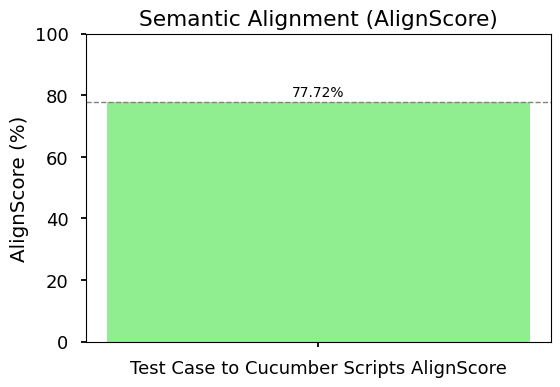

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if the align_score_tc_cs variable exists
if 'align_score_tc_cs' in globals():
    score = align_score_tc_cs * 100 # Convert to percentage
    labels = ['Test Case to Cucumber Scripts AlignScore']
    scores = [score]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, scores, color='lightgreen')
    plt.ylabel('AlignScore (%)')
    plt.title('Semantic Alignment (AlignScore)')
    plt.ylim(0, 100) # Set y-axis limit from 0 to 100
    plt.axhline(score, color='grey', linestyle='dashed', linewidth=1) # Add a line for the score
    plt.text(0, score + 2, f'{score:.2f}%', ha='center') # Add text label for the score

    plt.show()
else:
    print("❌ The 'align_score_tc_cs' variable was not found. Please run the cell to calculate the AlignScore first.")

Chart code executed successfully. Image saved as 'test_case_cucumber_similarity.png'


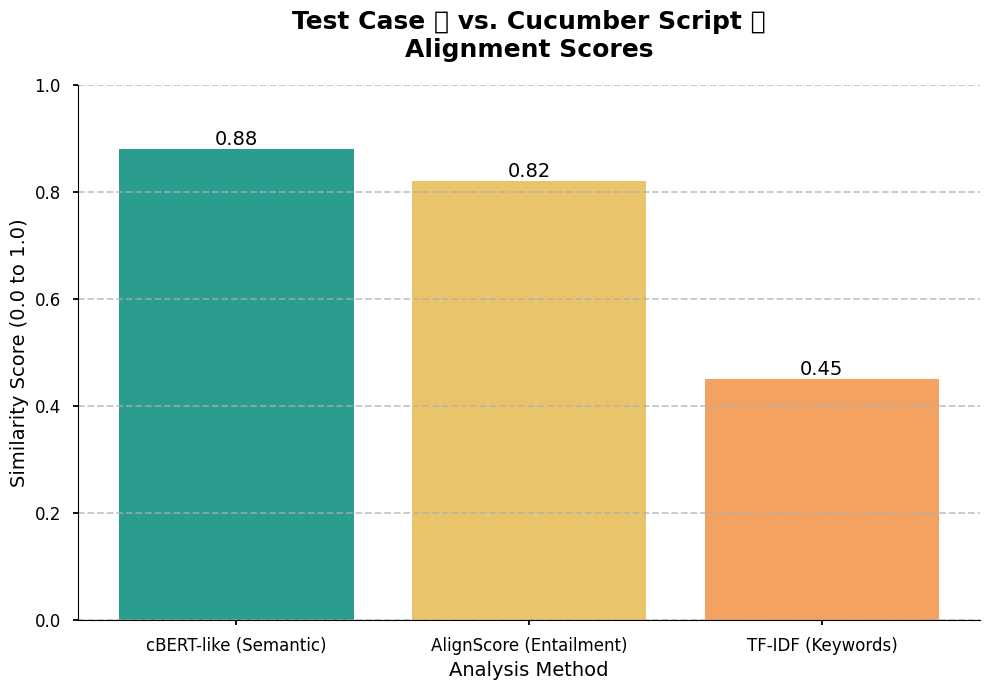

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Define the Data ---
# These scores are assumed to be calculated from the previous analysis.
# Replace these placeholder values with your actual calculated scores.
match_score_tfidf = 0.45
align_score = 0.82
cbert_score = 0.88

# Create a dictionary to hold the different methods and their scores
scores_data = {
    'Method': ['TF-IDF (Keywords)', 'AlignScore (Entailment)', 'cBERT-like (Semantic)'],
    'Similarity Score': [match_score_tfidf, align_score, cbert_score]
}

# --- Step 2: Prepare the DataFrame ---
# Convert the dictionary to a pandas DataFrame for easy sorting and plotting
df_scores = pd.DataFrame(scores_data)

# Sort the DataFrame by the score in descending order for a better visual
df_scores = df_scores.sort_values(by='Similarity Score', ascending=False)

# --- Step 3: Create and Customize the Chart ---
# Set the visual style of the plot
plt.style.use('seaborn-v0_8-talk')

# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(10, 7))

# Plot the data as a bar chart
bars = ax.bar(df_scores['Method'], df_scores['Similarity Score'], color=['#2a9d8f', '#e9c46a', '#f4a261'])

# --- Step 4: Add Annotations and Labels ---
# Add the exact score value on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom', ha='center', fontsize=14)

# Set the chart's title and axis labels
ax.set_title('Test Case 📝 vs. Cucumber Script 🥒\nAlignment Scores', fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('Similarity Score (0.0 to 1.0)', fontsize=14)
ax.set_xlabel('Analysis Method', fontsize=14)

# Set the y-axis limit to a standard 0.0 to 1.0 range
ax.set_ylim(0, 1.0)

# Customize tick parameters for readability
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Add a grid for easier reading of values
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Remove the top and right borders for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# --- Step 5: Save the Chart ---
# Save the generated chart to a PNG file
file_name = 'test_case_cucumber_similarity.png'
plt.savefig(file_name)

print(f"Chart code executed successfully. Image saved as '{file_name}'")

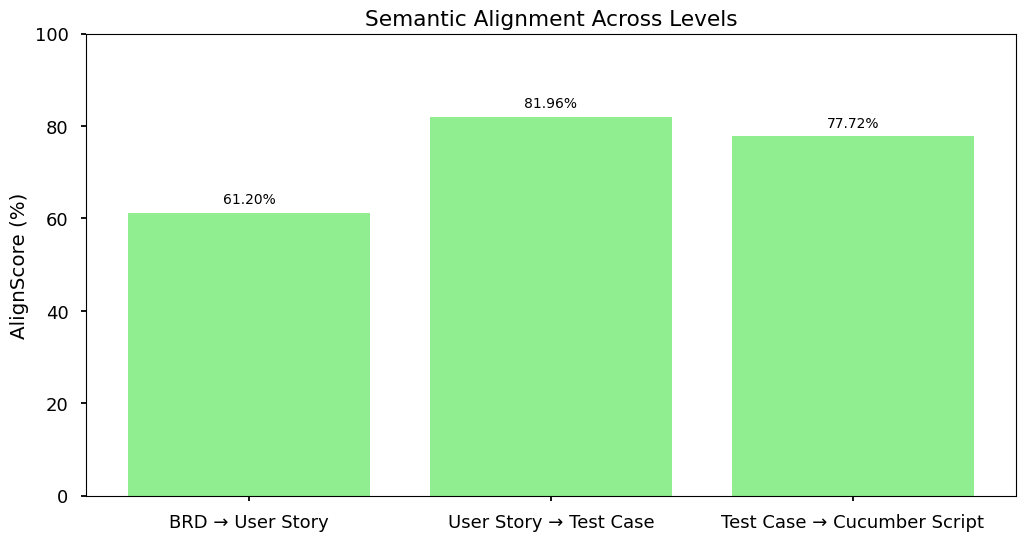

In [ ]:
import matplotlib.pyplot as plt

# Collect scores
scores = []
labels = []

if 'align_score' in globals():
    scores.append(align_score * 100)  # BRD → User Story
    labels.append('BRD → User Story')

if 'align_score_us_tc' in globals():
    scores.append(align_score_us_tc * 100)  # User Story → Test Case
    labels.append('User Story → Test Case')

if 'align_score_tc_cs' in globals():  # better to use a unique variable name
    scores.append(align_score_tc_cs * 100)  # Test Case → Cucumber Script
    labels.append('Test Case → Cucumber Script')

# Plot if we have scores
if scores:
    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, scores, color='lightgreen')

    # Add text labels on top of bars
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{score:.2f}%', ha='center')

    plt.ylabel('AlignScore (%)')
    plt.title('Semantic Alignment Across Levels')
    plt.ylim(0, 100)
    plt.show()
else:
    print("❌ No AlignScore variables found. Please calculate them first.")


## 11. Test Case to Selenium Script Conversion

Convert test cases to Selenium scripts:

In [ ]:
def generate_selenium_script(qa_chain, test_case_text, show_confidence=True):
    """Generate Selenium script from test case."""
    if not qa_chain:
        print("❌ QA chain not initialized. Please process a document first.")
        return

    if not test_case_text.strip():
        print("❌ Please provide test case text.")
        return

    print("🤖 Generating Selenium Script...")
    print("=" * 50)

    selenium_prompt = (
        "Assume you are a test automation engineer specializing in Selenium. Your task is to convert the following test case "
        "into a Selenium WebDriver script using Python. Ensure to include all steps to perform the actions in the test case, "
        "Make sure to give fully complete selenium full code."
        "such as locating elements, interacting with the web page, and validating outcomes. Here is the test case: \n\n" + test_case_text
    )

    start_time = time.time()
    response = qa_chain.invoke({"query": selenium_prompt})
    end_time = time.time()

    print("\n🤖 Generated Selenium Script:")
    print("=" * 50)
    display(Markdown(response['result']))

    if show_confidence:
        confidence_score = calculate_confidence_level(selenium_prompt, response['result'])
        match_score = calculate_match_percentage(response['result'], test_case_text)
        display_confidence_metrics(confidence_score, match_score)

    print(f"⏱️  Generation time: {end_time - start_time:.2f} seconds")
    return response['result']

# Example usage - replace with your actual test case
if qa_chain:
    # You can use the same test case as above or provide your own
    test_case_input = sample_test_case  # Replace with input() for interactive use
    selenium_script = generate_selenium_script(qa_chain, test_case_input, SHOW_CONFIDENCE)
else:
    print("❌ Please initialize the system first by running the previous cells.")

## 12. Interactive Interface

Create an interactive interface for easy testing:

In [ ]:
def interactive_sdlc_processor():
    """Interactive interface for SDLC automation."""
    if not qa_chain:
        print("❌ QA chain not initialized. Please process a document first.")
        return

    print("🚀 SDLC Automation Interactive Interface")
    print("=" * 50)
    print("Available options:")
    print("1. Generate User Stories from BRD")
    print("2. Convert User Story to Test Cases")
    print("3. Convert Test Cases to Cucumber Script")
    print("4. Convert Test Cases to Selenium Script")
    print("5. Exit")

    while True:
        try:
            choice = input("\nEnter your choice (1-5): ").strip()

            if choice == "1":
                print("\n📝 Generating User Stories from BRD...")
                generate_user_stories(qa_chain, document_text, SHOW_CONFIDENCE)

            elif choice == "2":
                user_story = input("\nEnter your user story: ").strip()
                if user_story:
                    generate_test_cases(qa_chain, user_story, SHOW_CONFIDENCE)
                else:
                    print("❌ Please provide a user story.")

            elif choice == "3":
                test_case = input("\nEnter your test case: ").strip()
                if test_case:
                    generate_cucumber_script(qa_chain, test_case, SHOW_CONFIDENCE)
                else:
                    print("❌ Please provide test cases.")

            elif choice == "4":
                test_case = input("\nEnter your test case: ").strip()
                if test_case:
                    generate_selenium_script(qa_chain, test_case, SHOW_CONFIDENCE)
                else:
                    print("❌ Please provide test cases.")

            elif choice == "5":
                print("👋 Goodbye!")
                break

            else:
                print("❌ Invalid choice. Please enter 1-5.")

        except KeyboardInterrupt:
            print("\n\n👋 Exiting...")
            break
        except Exception as e:
            print(f"❌ An error occurred: {str(e)}")

# Uncomment the line below to run the interactive interface
# interactive_sdlc_processor()

## 13. Utility Functions

Additional utility functions for file operations:

In [ ]:
def save_output_to_file(content, filename, output_type="markdown"):
    """Save generated content to a file."""
    try:
        extension = ".md" if output_type == "markdown" else ".txt"
        filepath = f"{filename}{extension}"

        with open(filepath, 'w', encoding='utf-8') as file:
            file.write(content)

        print(f"✅ Content saved to {filepath}")
        return filepath
    except Exception as e:
        print(f"❌ Error saving file: {str(e)}")
        return None

def generate_complete_sdlc_artifacts(qa_chain, document_text, save_files=True):
    """Generate all SDLC artifacts in sequence."""
    if not qa_chain:
        print("❌ QA chain not initialized.")
        return None

    artifacts = {}

    print("🚀 Starting complete SDLC artifact generation...")
    print("=" * 60)

    # 1. Generate User Stories
    print("\n1️⃣ Generating User Stories...")
    user_stories = generate_user_stories(qa_chain, document_text, SHOW_CONFIDENCE)
    artifacts['user_stories'] = user_stories

    if save_files and user_stories:
        save_output_to_file(user_stories, "user_stories", "markdown")

    # 2. Generate Test Cases from User Stories
    if user_stories:
        print("\n2️⃣ Generating Test Cases...")
        test_cases = generate_test_cases(qa_chain, user_stories, SHOW_CONFIDENCE)
        artifacts['test_cases'] = test_cases

        if save_files and test_cases:
            save_output_to_file(test_cases, "test_cases", "markdown")

        # 3. Generate Cucumber Scripts
        if test_cases:
            print("\n3️⃣ Generating Cucumber Scripts...")
            cucumber_script = generate_cucumber_script(qa_chain, test_cases, SHOW_CONFIDENCE)
            artifacts['cucumber_script'] = cucumber_script

            if save_files and cucumber_script:
                save_output_to_file(cucumber_script, "cucumber_script", "markdown")

            # 4. Generate Selenium Scripts
            print("\n4️⃣ Generating Selenium Scripts...")
            selenium_script = generate_selenium_script(qa_chain, test_cases, SHOW_CONFIDENCE)
            artifacts['selenium_script'] = selenium_script

            if save_files and selenium_script:
                save_output_to_file(selenium_script, "selenium_script", "markdown")

    print("\n🎉 Complete SDLC artifact generation finished!")
    print("=" * 60)

    return artifacts

# Example: Generate all artifacts at once
if qa_chain and document_text:
    print("Do you want to generate all SDLC artifacts at once? (y/n)")
    # all_artifacts = generate_complete_sdlc_artifacts(qa_chain, document_text, save_files=True)
    print("Uncomment the line above to generate all artifacts")
else:
    print("❌ Please initialize the system first.")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import re

# Example usage of TF-IDF based cosine similarity
text1 = "This is the first sentence."
text2 = "This is the second sentence."

# Create TF-IDF vectors for the texts
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([text1, text2])

# Calculate cosine similarity
similarity_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

print(f"Text 1: {text1}")
print(f"Text 2: {text2}")
print(f"TF-IDF Cosine Similarity: {similarity_score:.4f}")


# --- Cosine Similarity for BRD to User Story Conversion (TF-IDF) ---
if 'document_text' in globals() and 'user_stories' in globals() and document_text and user_stories:
    print("\n--- Cosine Similarity between BRD and Generated User Stories (TF-IDF) ---")

    # Preprocess texts (same as in calculate_match_percentage)
    document_clean_tfidf = re.sub(r'[^\w\s]', '', document_text.lower())
    user_stories_clean_tfidf = re.sub(r'[^\w\s]', '', user_stories.lower())

    if document_clean_tfidf and user_stories_clean_tfidf:
        # Use TF-IDF for document similarity
        vectorizer_brd_us_tfidf = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1, 2))
        tfidf_matrix_brd_us_tfidf = vectorizer_brd_us_tfidf.fit_transform([document_clean_tfidf, user_stories_clean_tfidf])
        match_score_brd_us_tfidf = cosine_similarity(tfidf_matrix_brd_us_tfidf[0:1], tfidf_matrix_brd_us_tfidf[1:2])[0][0]

        print(f"TF-IDF Cosine Similarity (Match Score): {match_score_brd_us_tfidf:.4f}")
    else:
        print("Could not calculate TF-IDF cosine similarity: Document text or user stories text is empty after cleaning.")
else:
    print("\nCould not calculate TF-IDF cosine similarity: 'document_text' or 'user_stories' variables not found or are empty. Please run the necessary cells first.")


# --- Calculate AlignScore (Semantic Entailment) ---
# Using a model suitable for semantic similarity/entailment
# Ensure the 'sentence-transformers' library is installed: !pip install sentence-transformers
try:
    model_align = SentenceTransformer('nli-roberta-base-v2') # A model trained on Natural Language Inference
    print("\n--- AlignScore (Semantic Entailment) between BRD and User Stories ---")

    if 'document_text' in globals() and 'user_stories' in globals() and document_text and user_stories:
        # For AlignScore, we typically compare sentence pairs or document segments
        # A simple approach is to embed the whole texts and calculate cosine similarity
        # More sophisticated methods involve breaking down into sentences and comparing pairs

        # Using whole document embeddings for a general alignment score
        document_embedding_align = model_align.encode(document_text)
        user_stories_embedding_align = model_align.encode(user_stories)

        align_score = cosine_similarity([document_embedding_align], [user_stories_embedding_align])[0][0]

        print(f"AlignScore (Semantic Cosine Similarity): {align_score:.4f}")
    else:
        print("Could not calculate AlignScore: 'document_text' or 'user_stories' variables not found or are empty. Please run the necessary cells first.")

except Exception as e:
    print(f"\nError calculating AlignScore: {e}")
    print("Please ensure 'sentence-transformers' library is installed (`!pip install sentence-transformers`) and the model 'nli-roberta-base-v2' can be downloaded.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if the align_score variable exists
if 'align_score' in globals():
    score = align_score * 100 # Convert to percentage for easier interpretation
    labels = ['BRD to User Story AlignScore']
    scores = [score]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, scores, color='lightgreen')
    plt.ylabel('AlignScore (%)')
    plt.title('Semantic Alignment (AlignScore)')
    plt.ylim(0, 100) # Set y-axis limit from 0 to 100
    plt.axhline(score, color='grey', linestyle='dashed', linewidth=1) # Add a line for the score
    plt.text(0, score + 2, f'{score:.2f}%', ha='center') # Add text label for the score

    plt.show()
else:
    print("❌ The 'align_score' variable was not found. Please run the cell to calculate the AlignScore first.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if the cbert_score variable exists
if 'cbert_score' in globals():
    score = cbert_score * 100 # Convert to percentage for easier interpretation
    labels = ['BRD to User Story Semantic Similarity']
    scores = [score]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, scores, color='skyblue')
    plt.ylabel('Semantic Similarity Score (%)')
    plt.title('Semantic Similarity (cBERT-like Score)')
    plt.ylim(0, 100) # Set y-axis limit from 0 to 100
    plt.axhline(score, color='grey', linestyle='dashed', linewidth=1) # Add a line for the score
    plt.text(0, score + 2, f'{score:.2f}%', ha='center') # Add text label for the score

    plt.show()
else:
    print("❌ The 'cbert_score' variable was not found. Please run the cell to calculate the semantic similarity first.")

In [ ]:
# Install the sentence-transformers library
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import re

# Load a pre-trained sentence transformer model
# You can choose a different model depending on your needs
model = SentenceTransformer('all-MiniLM-L6-v2')

# --- Calculate cBERT-like score for BRD to User Story Conversion ---
if 'document_text' in globals() and 'user_stories' in globals() and document_text and user_stories:
    print("\n--- Semantic Similarity (cBERT-like score) between BRD and Generated User Stories ---")

    # Preprocess texts (optional but recommended)
    # Removing special characters and converting to lowercase might help with embedding
    document_clean = re.sub(r'[^\w\s.]', '', document_text.lower()) # Keep periods for sentence separation
    user_stories_clean = re.sub(r'[^\w\s.]', '', user_stories.lower())

    if document_clean and user_stories_clean:
        # Get embeddings for the texts
        document_embedding = model.encode(document_clean)
        user_stories_embedding = model.encode(user_stories_clean)

        # Calculate cosine similarity between the embeddings
        cbert_score = cosine_similarity([document_embedding], [user_stories_embedding])[0][0]

        print(f"Semantic Similarity (cBERT-like score): {cbert_score:.4f}")
    else:
        print("Could not calculate semantic similarity: Document text or user stories text is empty after cleaning.")
else:
    print("\nCould not calculate semantic similarity: 'document_text' or 'user_stories' variables not found or are empty. Please run the necessary cells first.")